# Mudmut Systematic Analysis

Systematically identifies which combinations of critical-volume rule (VCV),
growth regulatory dynamic, and angle distributions push simulated *mud* mutant
lineages toward the experimental mudmut phenotype (smaller, less populous than WT).

**Notebook structure**
- Section 0 — Setup: load data, define references and helpers
- Section 1 — DIV distribution filter (WT sims)
  - 1.0 Sanity check: APICAL independence in WT
  - 1a Main filter charts + accepted conditions
- Section 1b — NB roundness filter
- Section 2+3 — Regulatory dynamics × VCV
- Section 4 — Angle distribution effects
- Section 5 — Synthesis

**Chart convention** (Sections 2+3 onward):
Y-axis = log₁₀(value / WT mean). Dotted line at 0 = WT mean.
Solid line = mudmut mean. Shaded band = mudmut ±1 SD.
Section 1 uses WT ±1 SD as the acceptance band instead.

---
## Section 0 — Setup

In [23]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

In [24]:
# Locate repo root (robust to different Jupyter launch directories)
REPO_ROOT = Path.cwd()
while not (REPO_ROOT / 'pyproject.toml').exists():
    if REPO_ROOT.parent == REPO_ROOT:
        raise RuntimeError('Could not find repo root (no pyproject.toml)')
    REPO_ROOT = REPO_ROOT.parent

sys.path.insert(0, str(REPO_ROOT / 'src'))
from npa.sim_viz import render_geo, load_sim_npz

SIM_METRICS_PATH = REPO_ROOT / 'data/sim/processed/sim_metrics_last.csv'
SIM_RUN_IDX_PATH = REPO_ROOT / 'data/sim/processed/sim_run_index.csv'
EXP_SUMMARY_PATH = REPO_ROOT / 'data/exp/processed/exp_summary.csv'
FIGURES_DIR      = REPO_ROOT / 'data/sim/processed/figures/analysis'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

sim = pd.read_csv(SIM_METRICS_PATH)
sim['run_id'] = sim['run_id'].astype(str).str.zfill(4)

run_idx = pd.read_csv(SIM_RUN_IDX_PATH, dtype=str)
run_idx['npz_row'] = run_idx['npz_row'].astype(int)

exp = pd.read_csv(EXP_SUMMARY_PATH)

print(f'sim_metrics : {len(sim)} rows, {sim["condition"].nunique()} conditions, '
      f'{sim.groupby(["condition","sim_id"]).size().unique().tolist()[0]} runs each')
print(f'run_index   : {len(run_idx)} rows')
print(f'exp_summary : {len(exp)} rows — genotypes: {list(exp["genotype"])}')
print(f'repo root   : {REPO_ROOT}')

sim_metrics : 1350 rows, 9 conditions, 10 runs each
run_index   : 1350 rows
exp_summary : 3 rows — genotypes: ['mudmut', 'nanobody', 'wt']
repo root   : /Users/skjannetty/bagherilab/neurogen-plane-rotation-analysis


In [25]:
METRICS = ['lin_area_vox', 'n_pros', 'n_dpn', 'dpn_area_vox', 'avg_dpn_area_vox']
TOP3    = ['lin_area_vox', 'n_pros', 'n_dpn']  # drive filter decisions

METRIC_LABELS = {
    'lin_area_vox':     'Lineage area (vox)',
    'n_pros':           'Pros count',
    'n_dpn':            'NB count',
    'dpn_area_vox':     'Total NB area (vox)',
    'avg_dpn_area_vox': 'Avg NB area (vox/cell)',
}
METRIC_DIRECTION = {
    'lin_area_vox':     'below WT',
    'n_pros':           'below WT',
    'n_dpn':            'above WT',   # mudmut > WT experimentally
    'dpn_area_vox':     'below WT',
    'avg_dpn_area_vox': 'below WT',
}

wt_row = exp[exp['genotype'] == 'wt'].iloc[0]
mm_row = exp[exp['genotype'] == 'mudmut'].iloc[0]

wt_ref = {m: (float(wt_row[f'{m}_mean']), float(wt_row[f'{m}_std'])) for m in METRICS}
mm_ref = {m: (float(mm_row[f'{m}_mean']), float(mm_row[f'{m}_std'])) for m in METRICS}

print(f'  {"Metric":<22} {"WT mean":>10} {"WT std":>9} {"MM mean":>10} {"MM std":>9} {"log10(MM/WT)":>13} {"Target":>10}')
print('  ' + '-' * 88)
for m in METRICS:
    wm, ws = wt_ref[m]
    mm, ms = mm_ref[m]
    lfc = np.log10(mm / wm)
    flag = ' ★' if m in TOP3 else ''
    print(f'  {m:<22} {wm:>10.2f} {ws:>9.2f} {mm:>10.2f} {ms:>9.2f} {lfc:>13.3f} {METRIC_DIRECTION[m]:>10}{flag}')

  Metric                    WT mean    WT std    MM mean    MM std  log10(MM/WT)     Target
  ----------------------------------------------------------------------------------------
  lin_area_vox              5568.45   1397.85    4074.92   1102.36        -0.136   below WT ★
  n_pros                      44.93     21.68      36.93     20.46        -0.085   below WT ★
  n_dpn                        1.00      0.00       1.80      0.86         0.254   above WT ★
  dpn_area_vox               577.05    473.84     320.14    257.46        -0.256   below WT
  avg_dpn_area_vox           577.05    473.84     217.87    217.30        -0.423   below WT


In [26]:
ANGLE_CONDITIONS = [
    {'tag': 'D0S0_R0S30',   'condition': 'divMean0Stdev0_rotMean0Stdev30',   'div_mean': 0,  'div_std': 0,  'rot_mean': 0,  'rot_std': 30, 'div_only': False, 'rot_only': True},
    {'tag': 'D0S0_R0S43',   'condition': 'divMean0Stdev0_rotMean0Stdev43',   'div_mean': 0,  'div_std': 0,  'rot_mean': 0,  'rot_std': 43, 'div_only': False, 'rot_only': True},
    {'tag': 'D0S0_R36S43',  'condition': 'divMean0Stdev0_rotMean36Stdev43',  'div_mean': 0,  'div_std': 0,  'rot_mean': 36, 'rot_std': 43, 'div_only': False, 'rot_only': True},
    {'tag': 'D0S30_R0S0',   'condition': 'divMean0Stdev30_rotMean0Stdev0',   'div_mean': 0,  'div_std': 30, 'rot_mean': 0,  'rot_std': 0,  'div_only': True,  'rot_only': False},
    {'tag': 'D0S30_R0S30',  'condition': 'divMean0Stdev30_rotMean0Stdev30',  'div_mean': 0,  'div_std': 30, 'rot_mean': 0,  'rot_std': 30, 'div_only': False, 'rot_only': False},
    {'tag': 'D0S43_R0S0',   'condition': 'divMean0Stdev43_rotMean0Stdev0',   'div_mean': 0,  'div_std': 43, 'rot_mean': 0,  'rot_std': 0,  'div_only': True,  'rot_only': False},
    {'tag': 'D36S43_R0S0',  'condition': 'divMean36Stdev43_rotMean0Stdev0',  'div_mean': 36, 'div_std': 43, 'rot_mean': 0,  'rot_std': 0,  'div_only': True,  'rot_only': False},
    {'tag': 'D36S30_R0S0',  'condition': 'divMean36Stdev30_rotMean0Stdev0',  'div_mean': 36, 'div_std': 30, 'rot_mean': 0,  'rot_std': 0,  'div_only': True,  'rot_only': False},
    {'tag': 'D36S30_R0S30', 'condition': 'divMean36Stdev30_rotMean0Stdev30', 'div_mean': 36, 'div_std': 30, 'rot_mean': 0,  'rot_std': 30, 'div_only': False, 'rot_only': False},
]
cond_df = pd.DataFrame(ANGLE_CONDITIONS).set_index('tag')

# 5 unique DIV distributions → groups used in Section 1
DIV_GROUPS = {
    'N(0,0)':   ['D0S0_R0S30',  'D0S0_R0S43',  'D0S0_R36S43'],
    'N(0,30)':  ['D0S30_R0S0',  'D0S30_R0S30'],
    'N(0,43)':  ['D0S43_R0S0'],
    'N(36,43)': ['D36S43_R0S0'],
    'N(36,30)': ['D36S30_R0S0', 'D36S30_R0S30'],
}

# availability check
expected = set(cond_df['condition'])
present  = set(sim['condition'].unique())
missing  = expected - present
if missing:
    print(f'WARNING: {len(missing)} condition(s) missing from sim_metrics_last.csv:')
    for c in sorted(missing):
        print(f'  {c}')
    print('Run extract_metrics.py then summarize_metrics.py before continuing.')
else:
    print('All 9 conditions present. ✓')

# run-count consistency check
counts = sim.groupby(['condition', 'sim_id']).size()
lo, hi = counts.min(), counts.max()
if lo != hi:
    print(f'WARNING: run counts vary ({lo}–{hi}):')
    print(counts[counts < hi].reset_index(name='n_runs').to_string(index=False))
else:
    print(f'Consistent run count: {lo} runs per (condition, sim_id). ✓')

All 9 conditions present. ✓
Consistent run count: 10 runs per (condition, sim_id). ✓


In [27]:
REG_DYN_ORDER  = ['NONE', 'NB-ABM', 'VOL-ABM', 'NB-PDE', 'VOL-PDE']
REG_DYN_COLORS = {
    'NONE':    '#888888',
    'NB-ABM':  '#4e9ed4',
    'VOL-ABM': '#5ab454',
    'NB-PDE':  '#e87b39',
    'VOL-PDE': '#d84444',
}


def fold_change_log(values, ref_mean):
    """log10(values / ref_mean), element-wise."""
    return np.log10(np.asarray(values, dtype=float) / ref_mean)


def draw_example_lineage(condition, sim_id, run_id=None, title='', ax=None):
    """
    Render the geo tensor for (condition, sim_id, run_id).
    If run_id is None, selects the run whose lin_area_vox is closest to the
    condition+sim_id mean (median-representative run).
    Returns the matplotlib Axes.
    """
    subset = sim[(sim['condition'] == condition) & (sim['sim_id'] == sim_id)]
    if subset.empty:
        raise ValueError(f'No rows for condition={condition}, sim_id={sim_id}')
    if run_id is None:
        mean_val = subset['lin_area_vox'].mean()
        run_id = str(subset.loc[
            (subset['lin_area_vox'] - mean_val).abs().idxmin(), 'run_id'
        ]).zfill(4)
    run_id = str(run_id).zfill(4)
    match = run_idx[
        (run_idx['condition'] == condition) &
        (run_idx['sim_id']    == sim_id) &
        (run_idx['run_id']    == run_id)
    ]
    if match.empty:
        raise ValueError(f'run_index has no entry for condition={condition}, '
                         f'sim_id={sim_id}, run_id={run_id}')
    npz_path = REPO_ROOT / match.iloc[0]['npz_path']
    row = int(match.iloc[0]['npz_row'])
    geo = load_sim_npz(npz_path, row)
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 5))
    tag_matches = cond_df[cond_df['condition'] == condition]
    tag = tag_matches.index[0] if len(tag_matches) else condition
    render_geo(geo, ax=ax, title=title or f'{tag} | {sim_id} | run {run_id}')
    ax.axis('off')
    return ax


def nb_circularity(geo_tensor, min_voxels=50):
    """
    Minimum 4π·area/perimeter² across NB connected components in geo_tensor.
    Components smaller than min_voxels are ignored as artifacts.
    Returns NaN if no qualifying components found.
    Used in Section 1b (not yet implemented).
    """
    from skimage.measure import label, regionprops
    nb_mask = (geo_tensor[..., 0] > 0).astype('uint8')
    labeled = label(nb_mask, connectivity=1)
    circularities = [
        (4 * np.pi * p.area) / (p.perimeter ** 2)
        for p in regionprops(labeled)
        if p.area >= min_voxels and p.perimeter > 0
    ]
    return float(np.min(circularities)) if circularities else float('nan')

---
## Section 1 — DIV Distribution Filter (WT Simulations)

**Question:** Which DIV_ROTATION distributions keep WT simulations within
±1 SD of the experimental WT mean on the three primary metrics?

Because `APICAL_AXIS_ROTATION_DISTRIBUTION` only acts after symmetric divisions,
and WT neuroblasts never divide symmetrically, APICAL has no effect on WT
outcomes. Only the 5 unique DIV distributions need to be compared.

**Filter criterion:** a DIV distribution is eliminated if any regulatory dynamic
bar falls outside the WT ±1 SD acceptance band on any of
`lin_area_vox`, `n_pros`, or `n_dpn`. The remaining two metrics are shown for
reference but do not drive the decision.

**Output:** `accepted_div_distributions`, `accepted_tags`, `accepted_conditions`
— used by all subsequent sections.

### Section 1.0 — Sanity check: APICAL independence in WT

For DIV groups with more than one condition (i.e. conditions that share the same
DIV distribution but differ only in APICAL), WT results should be essentially
identical. Boxes for the same regulatory dynamic color at different APICAL conditions
should overlap completely — this confirms APICAL has no effect on WT outcomes.

If boxes differ meaningfully between conditions within a group, investigate before proceeding.

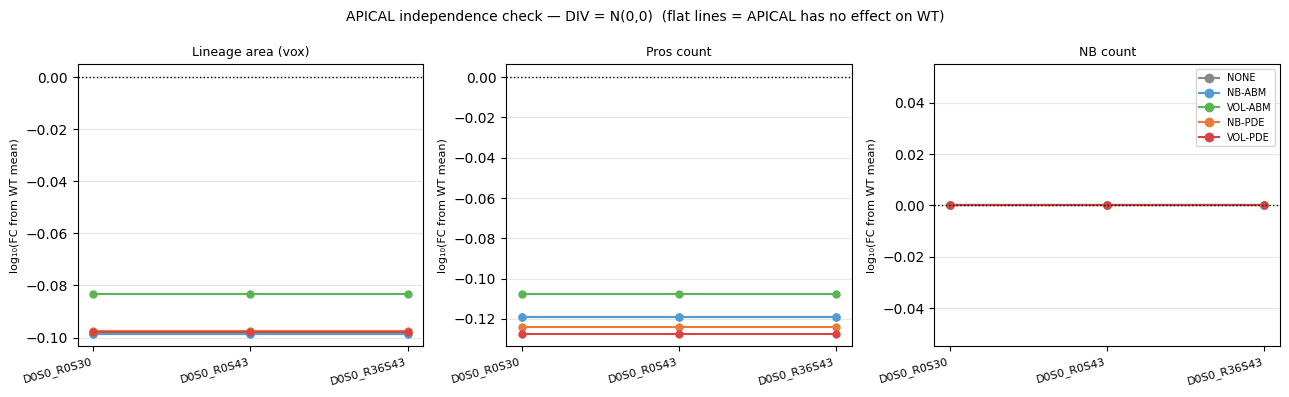

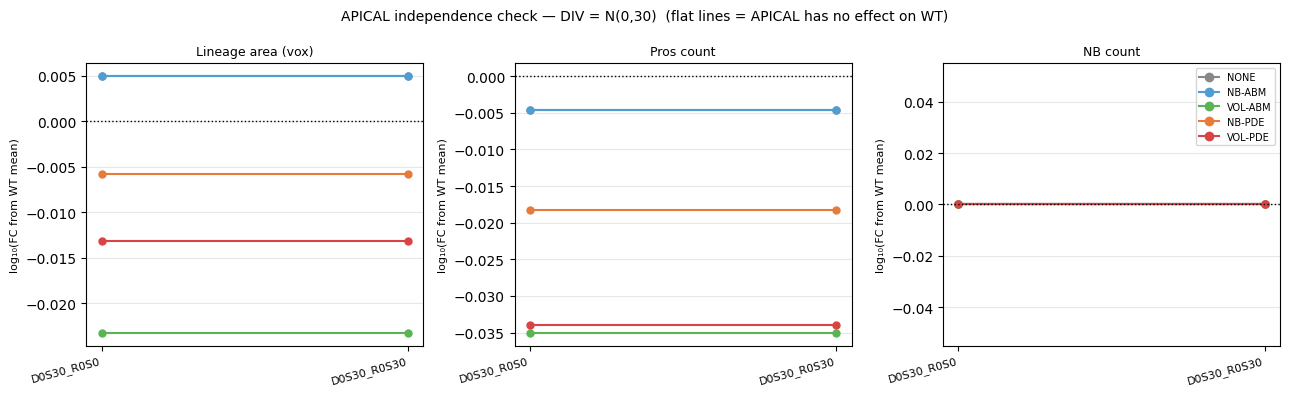

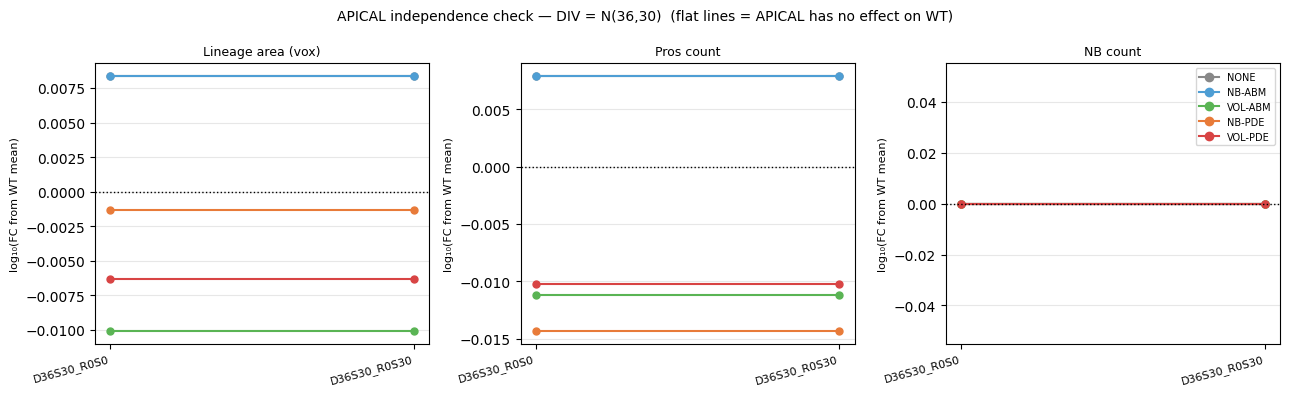

In [28]:
sim_wt = sim[sim['genotype'] == 'wt']
multi_groups = {k: v for k, v in DIV_GROUPS.items() if len(v) > 1}

for div_label, tags in multi_groups.items():
    conditions = [cond_df.loc[t, 'condition'] for t in tags]
    fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=False)
    fig.suptitle(
        f'APICAL independence check — DIV = {div_label}  '
        f'(flat lines = APICAL has no effect on WT)',
        fontsize=10
    )
    for ax, metric in zip(axes, TOP3):
        wt_mean = wt_ref[metric][0]
        for reg_dyn in REG_DYN_ORDER:
            x_vals, y_vals = [], []
            for xi, (tag, cond) in enumerate(zip(tags, conditions)):
                runs = sim_wt[
                    (sim_wt['condition'] == cond) &
                    (sim_wt['regulatory_dynamic'] == reg_dyn)
                ][metric]
                if runs.empty:
                    continue
                x_vals.append(xi)
                y_vals.append(fold_change_log(runs, wt_mean).mean())
            if x_vals:
                ax.plot(x_vals, y_vals,
                        marker='o', color=REG_DYN_COLORS[reg_dyn],
                        label=reg_dyn, linewidth=1.5, markersize=5)
        ax.axhline(0, color='black', linestyle=':', linewidth=1)
        ax.set_xticks(range(len(tags)))
        ax.set_xticklabels(tags, rotation=15, ha='right', fontsize=8)
        ax.set_ylabel('log\u2081\u2080(FC from WT mean)', fontsize=8)
        ax.set_title(METRIC_LABELS[metric], fontsize=9)
        ax.grid(axis='y', alpha=0.3)

    legend_handles = [
        Line2D([0], [0], color=REG_DYN_COLORS[d], marker='o', label=d, linewidth=1.5)
        for d in REG_DYN_ORDER
    ]
    axes[-1].legend(handles=legend_handles, fontsize=7, loc='best')
    plt.tight_layout()
    safe = div_label.replace('(', '').replace(')', '').replace(',', '_').replace(' ', '')
    fig.savefig(FIGURES_DIR / f'sec1_apical_sanity_{safe}.png', dpi=120, bbox_inches='tight')
    plt.show()

### Section 1a — Main filter charts

One chart per metric. X-axis = 5 DIV distributions; bars = regulatory dynamics
(pooling conditions within each DIV group since APICAL has been confirmed not
to affect WT above). Shaded band = experimental WT ±1 SD acceptance region.

In [29]:
def wt_filter_chart(metric, figsize=(13, 5)):
    """
    Grouped box-and-whisker chart for one metric: WT sim log fold change from
    experimental WT mean. X-axis = 5 DIV groups; boxes = 5 regulatory dynamics
    (colored, side-by-side within each group). Shaded band = WT ±1 SD acceptance
    region (symmetric in log space). Median annotated on each box.
    n_dpn has wt_std=0; a small visual band is drawn in its place.
    """
    wt_mean, wt_std = wt_ref[metric]
    zero_std = (wt_std == 0)
    if zero_std:
        band_lo, band_hi = -0.05, 0.05
        band_label = 'WT ±1 SD (std=0; band is visual only)'
    else:
        band_hi = np.log10((wt_mean + wt_std) / wt_mean)
        band_lo = -band_hi
        band_label = 'WT ±1 SD (acceptance)'

    fig, ax = plt.subplots(figsize=figsize)
    ax.axhspan(band_lo, band_hi, alpha=0.15, color='gray', zorder=0, label=band_label)
    ax.axhline(0, color='black', linestyle=':', linewidth=1.5, zorder=1, label='WT mean')

    div_labels = list(DIV_GROUPS.keys())
    n_boxes  = len(REG_DYN_ORDER)
    box_w    = 0.14
    offsets  = np.linspace(-(n_boxes - 1) / 2, (n_boxes - 1) / 2, n_boxes) * box_w

    for gi, div_label in enumerate(div_labels):
        tags       = DIV_GROUPS[div_label]
        conditions = [cond_df.loc[t, 'condition'] for t in tags]
        for bi, reg_dyn in enumerate(REG_DYN_ORDER):
            runs = sim_wt[
                (sim_wt['condition'].isin(conditions)) &
                (sim_wt['regulatory_dynamic'] == reg_dyn)
            ][metric]
            if runs.empty:
                continue
            lfc = fold_change_log(runs, wt_mean)
            x   = gi + offsets[bi]
            bp  = ax.boxplot(
                [lfc],
                positions=[x],
                widths=box_w * 0.85,
                patch_artist=True,
                medianprops={'color': 'black', 'linewidth': 1.2},
                whiskerprops={'linewidth': 0.7},
                capprops={'linewidth': 0.7},
                flierprops={'marker': 'o', 'markersize': 1.5, 'linestyle': 'none'},
                manage_ticks=False,
                zorder=2,
            )
            bp['boxes'][0].set_facecolor(REG_DYN_COLORS[reg_dyn])
            bp['boxes'][0].set_alpha(0.8)

            med = float(np.median(lfc))
            upper_cap = bp['caps'][1].get_ydata()[0]
            lower_cap = bp['caps'][0].get_ydata()[0]
            if med >= 0:
                ax.text(x, upper_cap + 0.005, f'{med:.2f}',
                        ha='center', va='bottom', fontsize=5.5, rotation=90)
            else:
                ax.text(x, lower_cap - 0.005, f'{med:.2f}',
                        ha='center', va='top', fontsize=5.5, rotation=90)

    ax.set_xticks(range(len(div_labels)))
    ax.set_xticklabels([f'DIV {d}' for d in div_labels], fontsize=9)
    flag = '  ★ filter metric' if metric in TOP3 else ''
    ax.set_title(f'{METRIC_LABELS[metric]} — WT sims vs experimental WT{flag}', fontsize=10)
    ax.set_ylabel('log₁₀(fold change from WT mean)')

    legend_handles = [
        ax.axhspan(0, 0, alpha=0.15, color='gray', label=band_label),
        Line2D([0], [0], color='black', linestyle=':', linewidth=1.5, label='WT mean'),
    ] + [
        plt.Rectangle((0, 0), 1, 1, fc=REG_DYN_COLORS[d], alpha=0.8, label=d)
        for d in REG_DYN_ORDER
    ]
    ax.legend(handles=legend_handles, fontsize=8, loc='upper right')
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    return fig

=== Filter metrics — drive the accepted_div_distributions decision ===


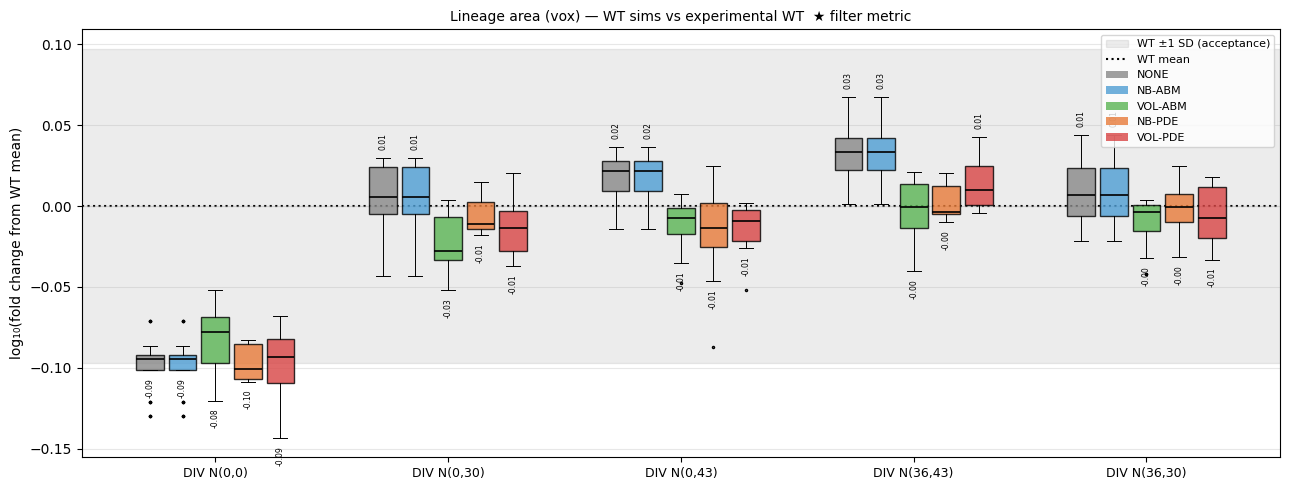

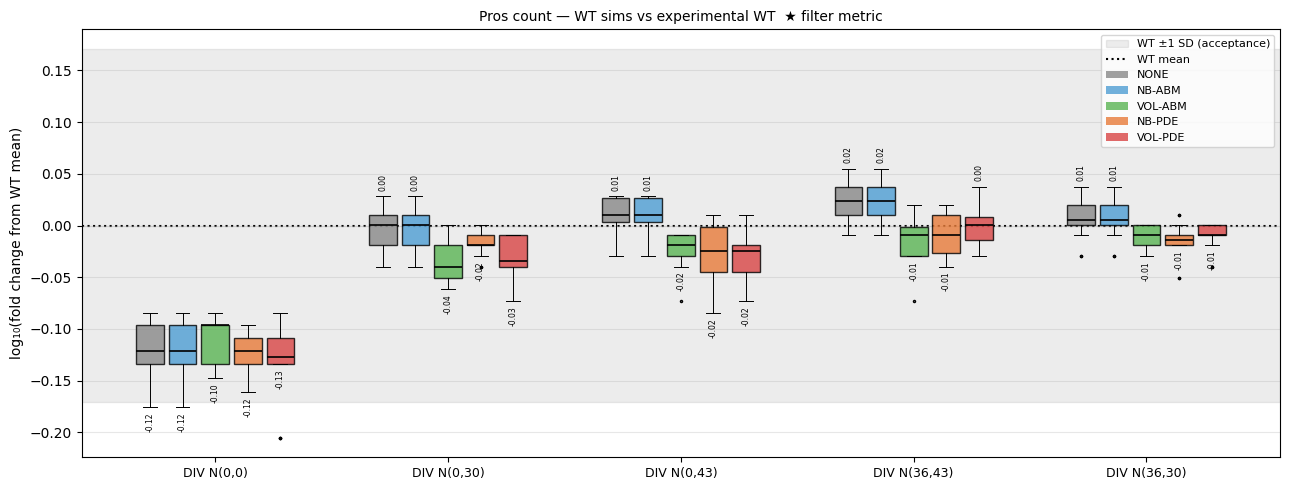

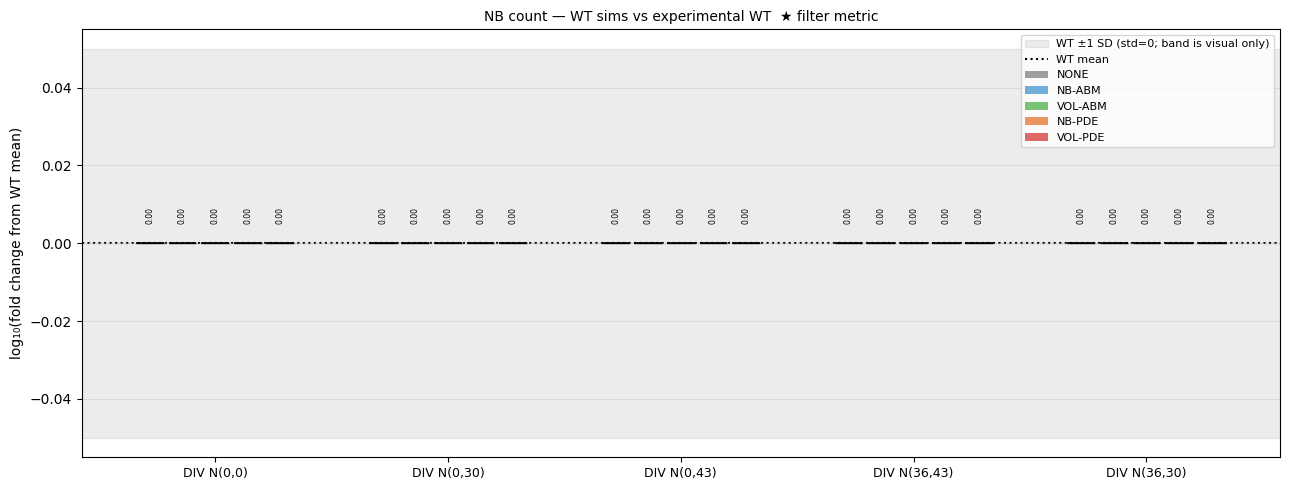

In [30]:
print('=== Filter metrics — drive the accepted_div_distributions decision ===')
for metric in TOP3:
    fig = wt_filter_chart(metric)
    fig.savefig(FIGURES_DIR / f'sec1a_wt_filter_{metric}.png', dpi=120, bbox_inches='tight')
    plt.show()

=== Reference metrics — shown for completeness, do not drive filter ===


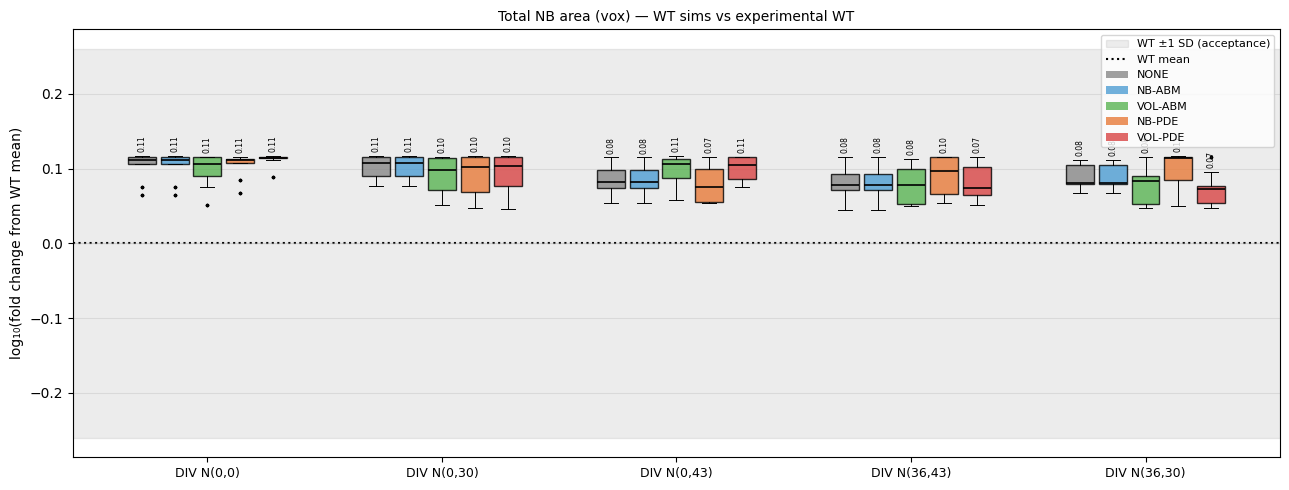

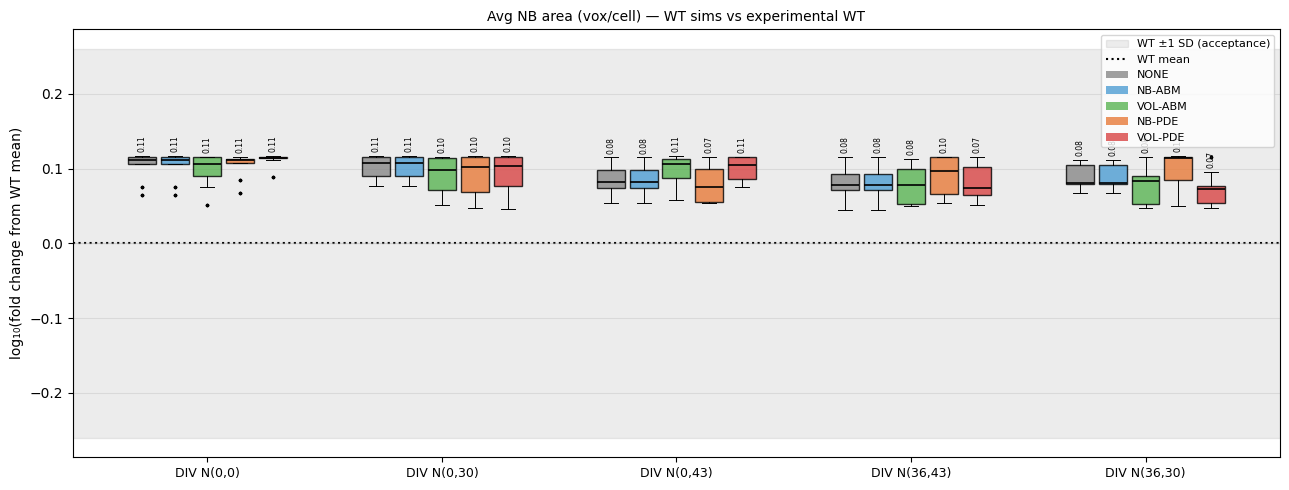

In [31]:
print('=== Reference metrics — shown for completeness, do not drive filter ===')
for metric in [m for m in METRICS if m not in TOP3]:
    fig = wt_filter_chart(metric)
    fig.savefig(FIGURES_DIR / f'sec1a_wt_filter_{metric}.png', dpi=120, bbox_inches='tight')
    plt.show()

In [32]:
# ── ANALYST EDIT ─────────────────────────────────────────────────────────────
# Eliminate a DIV distribution if any bar falls outside the WT ±1 SD band
# on any filter metric (lin_area_vox, n_pros, n_dpn).
# Valid keys: 'N(0,0)', 'N(0,30)', 'N(0,43)', 'N(36,43)', 'N(36,30)'

eliminated_div_distributions = []

# ── do not edit below ────────────────────────────────────────────────────────
accepted_div_distributions = [d for d in DIV_GROUPS if d not in eliminated_div_distributions]
accepted_tags       = [t for d in accepted_div_distributions for t in DIV_GROUPS[d]]
accepted_conditions = cond_df.loc[cond_df.index.isin(accepted_tags), 'condition'].tolist()

print(f'Eliminated : {eliminated_div_distributions or "none"}')
print(f'Accepted DIV distributions ({len(accepted_div_distributions)}): {accepted_div_distributions}')
print(f'Accepted tags       ({len(accepted_tags):2d}): {accepted_tags}')
print(f'Accepted conditions ({len(accepted_conditions):2d}): {accepted_conditions}')

Eliminated : none
Accepted DIV distributions (5): ['N(0,0)', 'N(0,30)', 'N(0,43)', 'N(36,43)', 'N(36,30)']
Accepted tags       ( 9): ['D0S0_R0S30', 'D0S0_R0S43', 'D0S0_R36S43', 'D0S30_R0S0', 'D0S30_R0S30', 'D0S43_R0S0', 'D36S43_R0S0', 'D36S30_R0S0', 'D36S30_R0S30']
Accepted conditions ( 9): ['divMean0Stdev0_rotMean0Stdev30', 'divMean0Stdev0_rotMean0Stdev43', 'divMean0Stdev0_rotMean36Stdev43', 'divMean0Stdev30_rotMean0Stdev0', 'divMean0Stdev30_rotMean0Stdev30', 'divMean0Stdev43_rotMean0Stdev0', 'divMean36Stdev43_rotMean0Stdev0', 'divMean36Stdev30_rotMean0Stdev0', 'divMean36Stdev30_rotMean0Stdev30']


### Section 1a gut-check — Example WT lineages

Visual confirmation that WT lineages look reasonable across accepted conditions.
Shows the smallest-sigma and largest-sigma accepted DIV conditions
using `sim61` (WT NONE dynamic, median-representative run).

Smallest σ_div accepted: D0S0_R0S30
Largest  σ_div accepted: D0S43_R0S0


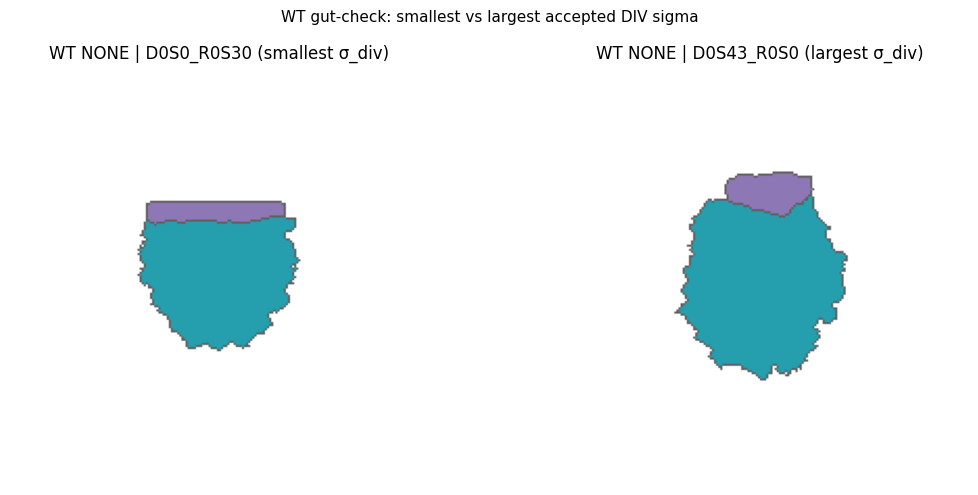

In [33]:
accepted_cond_df = cond_df.loc[cond_df.index.isin(accepted_tags)]

min_sigma_tag = accepted_cond_df['div_std'].idxmin()
max_sigma_tag = accepted_cond_df['div_std'].idxmax()
min_sigma_cond = cond_df.loc[min_sigma_tag, 'condition']
max_sigma_cond = cond_df.loc[max_sigma_tag, 'condition']

print(f'Smallest σ_div accepted: {min_sigma_tag}')
print(f'Largest  σ_div accepted: {max_sigma_tag}')

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
draw_example_lineage(
    min_sigma_cond, 'vcv1_noreg', ax=axes[0],
    title=f'WT NONE | {min_sigma_tag} (smallest σ_div)'
)
draw_example_lineage(
    max_sigma_cond, 'vcv1_noreg', ax=axes[1],
    title=f'WT NONE | {max_sigma_tag} (largest σ_div)'
)
plt.suptitle('WT gut-check: smallest vs largest accepted DIV sigma', fontsize=11)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'sec1a_wt_gutcheck.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Section 1b — NB Roundness Filter

**Question:** Do any accepted angle conditions produce systematically flat or elongated neuroblasts?

**Motivation:** when many divisions occur along the same axis, NBs can become very flat.
A circularity threshold is calibrated visually here and applied to remove conditions
with degenerate NB morphology before the mudmut analysis.

**Data:** WT sims (sim61–65) across `accepted_conditions`, all runs, last timepoint.

**Metric:** min NB circularity = 4π·area/perimeter² across all NB components in a geo tensor.
Circularity = 1 for a perfect circle; near 0 for very elongated or flat shapes.

**Output:** `accepted_conditions` and `accepted_tags` updated with roundness exclusions applied.

In [34]:
WT_IDS = ['vcv1_noreg', 'vcv1_nb_abm', 'vcv1_vol_abm', 'vcv1_nb_pde', 'vcv1_vol_pde']

circ_mask = (
    run_idx['condition'].isin(accepted_conditions) &
    run_idx['sim_id'].isin(WT_IDS)
)
circ_run_idx = run_idx[circ_mask].copy()

n_total = len(circ_run_idx)
print(f'Computing NB circularity for {n_total} runs '
      f'({len(accepted_conditions)} conditions × {len(WT_IDS)} sim_ids × 10 runs)...')

circ_records = []
for npz_path_str, group in circ_run_idx.groupby('npz_path'):
    npz_path = REPO_ROOT / npz_path_str
    with np.load(npz_path) as data:
        geo_all = data['geo']
    for _, row in group.iterrows():
        geo = geo_all[int(row['npz_row'])]
        circ = nb_circularity(geo)
        circ_records.append({
            'condition':       row['condition'],
            'sim_id':          row['sim_id'],
            'run_id':          row['run_id'],
            'min_circularity': circ,
        })

circ_df = pd.DataFrame(circ_records)
cond_to_tag = {v: k for k, v in cond_df['condition'].items()}
circ_df['tag'] = circ_df['condition'].map(cond_to_tag)

print(f'Done. Circularity range: [{circ_df["min_circularity"].min():.3f}, '
      f'{circ_df["min_circularity"].max():.3f}]')
print()
print(circ_df.groupby('tag')['min_circularity'].describe().round(3).to_string())

Computing NB circularity for 450 runs (9 conditions × 5 sim_ids × 10 runs)...
Done. Circularity range: [0.362, 0.810]

              count   mean    std    min    25%    50%    75%    max
tag                                                                 
D0S0_R0S30     50.0  0.413  0.027  0.362  0.397  0.410  0.427  0.474
D0S0_R0S43     50.0  0.413  0.027  0.362  0.397  0.410  0.427  0.474
D0S0_R36S43    50.0  0.413  0.027  0.362  0.397  0.410  0.427  0.474
D0S30_R0S0     50.0  0.599  0.067  0.490  0.561  0.590  0.639  0.781
D0S30_R0S30    50.0  0.599  0.067  0.490  0.561  0.590  0.639  0.781
D0S43_R0S0     50.0  0.685  0.041  0.577  0.653  0.685  0.716  0.769
D36S30_R0S0    50.0  0.687  0.053  0.593  0.656  0.684  0.723  0.783
D36S30_R0S30   50.0  0.687  0.053  0.593  0.656  0.684  0.723  0.783
D36S43_R0S0    50.0  0.722  0.047  0.614  0.682  0.719  0.758  0.810


/var/folders/2c/ggmnjcgs6zv79p4w57qtvtr80000gn/T/ipykernel_82418/2126886441.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_tag, labels=tag_order, patch_artist=True,


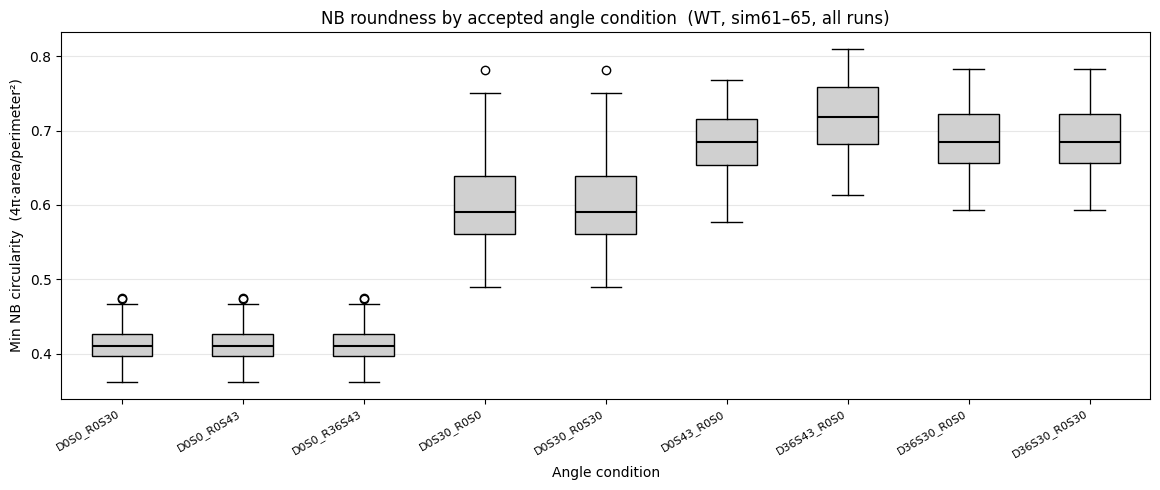

In [35]:
tag_order = [t for t in accepted_tags if t in circ_df['tag'].values]
data_by_tag = [circ_df[circ_df['tag'] == t]['min_circularity'].dropna().values
               for t in tag_order]

fig, ax = plt.subplots(figsize=(max(8, len(tag_order) * 1.3), 5))
bp = ax.boxplot(data_by_tag, labels=tag_order, patch_artist=True,
                medianprops={'color': 'black', 'linewidth': 1.5})
for patch in bp['boxes']:
    patch.set_facecolor('#d0d0d0')

ax.set_xlabel('Angle condition')
ax.set_ylabel('Min NB circularity  (4π·area/perimeter²)')
ax.set_title('NB roundness by accepted angle condition  (WT, sim61–65, all runs)')
ax.set_xticklabels(tag_order, rotation=30, ha='right', fontsize=8)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'sec1b_roundness_boxplot.png', dpi=120, bbox_inches='tight')
plt.show()

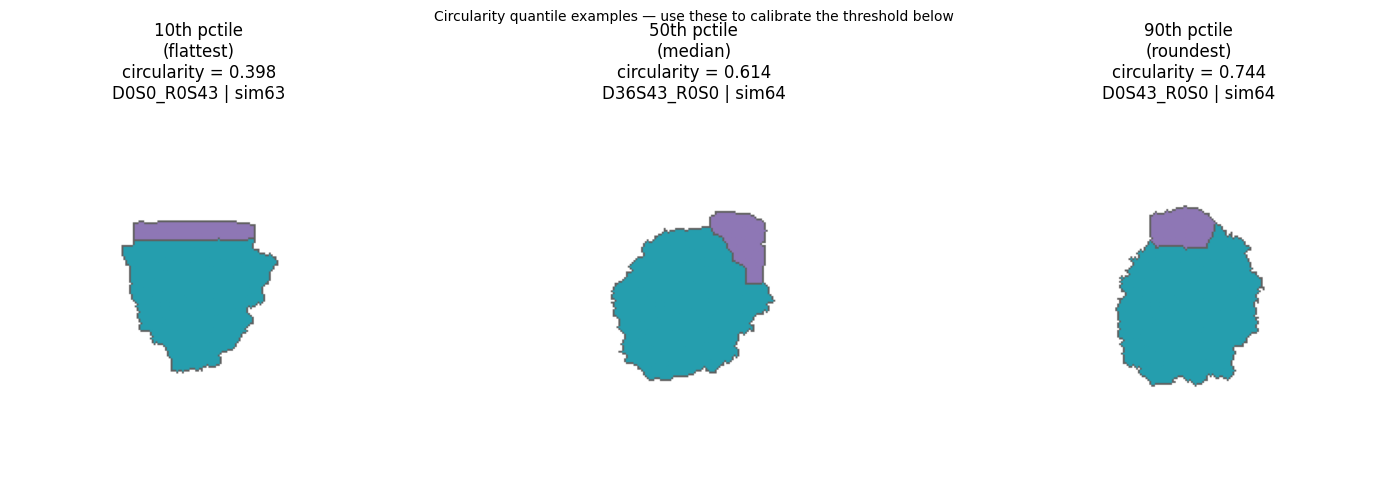

In [36]:
quantiles    = [0.10, 0.50, 0.90]
quantile_labels = ['10th pctile\n(flattest)', '50th pctile\n(median)', '90th pctile\n(roundest)']

all_sorted = (
    circ_df.dropna(subset=['min_circularity'])
           .sort_values('min_circularity')
           .reset_index(drop=True)
)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, q, qlabel in zip(axes, quantiles, quantile_labels):
    idx = int(q * (len(all_sorted) - 1))
    row = all_sorted.iloc[idx]
    draw_example_lineage(
        row['condition'], row['sim_id'], run_id=row['run_id'],
        title=f'{qlabel}\ncircularity = {row["min_circularity"]:.3f}\n{row["tag"]} | {row["sim_id"]}',
        ax=ax,
    )

plt.suptitle('Circularity quantile examples — use these to calibrate the threshold below',
             fontsize=10)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'sec1b_roundness_quantile_examples.png', dpi=120, bbox_inches='tight')
plt.show()

### Threshold calibration

Review the box plots and quantile examples above.

Set `circularity_threshold` in the cell below to the minimum acceptable **median**
min-circularity. Any accepted condition whose median falls below the threshold will
be excluded from Sections 2+3 onward.

- Set to `0` to keep all conditions (skip roundness filtering).
- A value around the 10th-percentile circularity shown above is a reasonable starting point.

In [37]:
# ── ANALYST EDIT ─────────────────────────────────────────────────────────────
# Conditions whose median min_circularity falls below this value are excluded.
# Set to 0 to skip roundness filtering.

circularity_threshold = .5

# ── do not edit below ────────────────────────────────────────────────────────
median_circ = circ_df.groupby('condition')['min_circularity'].median()

roundness_excluded_conditions = [
    c for c in accepted_conditions
    if median_circ.get(c, 1.0) < circularity_threshold
]
accepted_conditions = [c for c in accepted_conditions if c not in roundness_excluded_conditions]
accepted_tags = [t for t in accepted_tags if cond_df.loc[t, 'condition'] in accepted_conditions]

if roundness_excluded_conditions:
    excl_tags = [cond_to_tag.get(c, c) for c in roundness_excluded_conditions]
    print(f'Roundness-excluded ({len(roundness_excluded_conditions)}): {excl_tags}')
else:
    print('All accepted conditions passed the roundness filter. ✓')
print(f'Remaining accepted conditions ({len(accepted_conditions)}): {accepted_tags}')

Roundness-excluded (3): ['D0S0_R0S30', 'D0S0_R0S43', 'D0S0_R36S43']
Remaining accepted conditions (6): ['D0S30_R0S0', 'D0S30_R0S30', 'D0S43_R0S0', 'D36S43_R0S0', 'D36S30_R0S0', 'D36S30_R0S30']


Lowest  circularity run: D0S30_R0S0 | sim65 | run 0007  (0.490)
Highest circularity run: D36S43_R0S0 | sim63 | run 0010  (0.810)


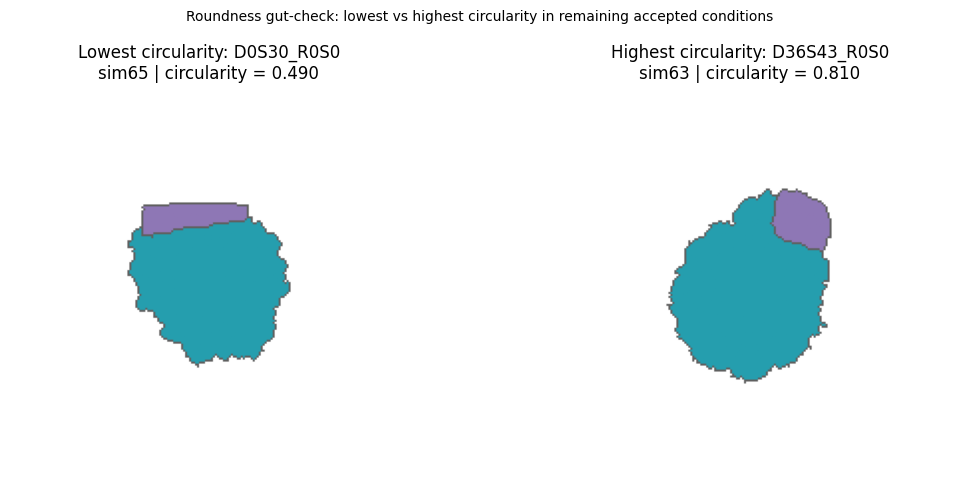

In [38]:
remaining_circ_df = circ_df[circ_df['condition'].isin(accepted_conditions)]
lo_run = remaining_circ_df.loc[remaining_circ_df['min_circularity'].idxmin()]
hi_run = remaining_circ_df.loc[remaining_circ_df['min_circularity'].idxmax()]

print(f'Lowest  circularity run: {lo_run["tag"]} | {lo_run["sim_id"]} | run {lo_run["run_id"]}  ({lo_run["min_circularity"]:.3f})')
print(f'Highest circularity run: {hi_run["tag"]} | {hi_run["sim_id"]} | run {hi_run["run_id"]}  ({hi_run["min_circularity"]:.3f})')

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
draw_example_lineage(
    lo_run['condition'], lo_run['sim_id'], run_id=lo_run['run_id'],
    title=f'Lowest circularity: {lo_run["tag"]}\n{lo_run["sim_id"]} | circularity = {lo_run["min_circularity"]:.3f}',
    ax=axes[0],
)
draw_example_lineage(
    hi_run['condition'], hi_run['sim_id'], run_id=hi_run['run_id'],
    title=f'Highest circularity: {hi_run["tag"]}\n{hi_run["sim_id"]} | circularity = {hi_run["min_circularity"]:.3f}',
    ax=axes[1],
)
plt.suptitle('Roundness gut-check: lowest vs highest circularity in remaining accepted conditions',
             fontsize=10)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'sec1b_roundness_gutcheck.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Section 2+3 — Regulatory Dynamics × VCV (mudmut)

**Question:** Which (regulatory dynamic, VCV mode) combinations push simulated mudmut below
the experimental WT mean? Which reach the experimental mudmut target?

**Data:** mudmut VCV=0 (sim51–55) and VCV=1 (sim41–45) across `accepted_conditions`.

**Layout:** one figure per metric. Each figure is a 2-row × 5-column grid:
- Rows: VCV=0 (top) / VCV=1 (bottom)
- Columns: NONE | NB-ABM | VOL-ABM | NB-PDE | VOL-PDE
- X-axis within each panel: accepted angle conditions
- Y-axis: log₁₀(value / experimental WT mean)

**Reference lines in every panel:**
- Dotted black line at y=0: experimental WT mean
- Solid blue line: experimental mudmut mean; shaded band = mudmut ±1 SD (symmetric in log space)

**Reading the grid:** compare across columns to see regulatory dynamic effects;
compare across rows to see VCV effect; read within a panel to see angle-condition sensitivity.

In [39]:
from matplotlib.patches import Patch

_COND_PALETTE = [
    '#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00',
    '#a65628', '#f781bf', '#999999', '#dede00',
]
COND_COLORS = {tag: _COND_PALETTE[i % len(_COND_PALETTE)]
               for i, tag in enumerate(accepted_tags)}

sim_mm = sim[sim['genotype'] == 'mudmut']


def mudmut_facet_chart(metric, figsize=(24, 10)):
    """
    2-row × 5-column facet chart for one metric.
    Rows: VCV mode (0=top, 1=bottom). Cols: regulatory dynamic.
    X-axis per panel: accepted angle conditions.
    Y-axis: log10(value / experimental WT mean).
    Each box shows the distribution of log FC across runs for one angle condition.
    Median annotated above/below each box.
    """
    wt_mean             = wt_ref[metric][0]
    mm_mean_val, mm_std = mm_ref[metric]
    mm_lfc              = np.log10(mm_mean_val / wt_mean)
    mm_half             = 0.05 if mm_std == 0 else np.log10(1 + mm_std / mm_mean_val)
    mm_lo, mm_hi        = mm_lfc - mm_half, mm_lfc + mm_half

    fig, axes = plt.subplots(2, len(REG_DYN_ORDER), figsize=figsize, sharey=True)

    for ri, vcv in enumerate([0, 1]):
        for ci, reg_dyn in enumerate(REG_DYN_ORDER):
            ax = axes[ri, ci]

            ax.axhspan(mm_lo, mm_hi, alpha=0.15, color='steelblue', zorder=0)
            ax.axhline(mm_lfc, color='steelblue', linewidth=1.2, zorder=1)
            ax.axhline(0, color='black', linestyle=':', linewidth=1, zorder=1)

            panel = sim_mm[
                (sim_mm['critical_volume_mode'] == vcv) &
                (sim_mm['regulatory_dynamic']   == reg_dyn) &
                (sim_mm['condition'].isin(accepted_conditions))
            ]

            data_by_tag = []
            for tag in accepted_tags:
                cond = cond_df.loc[tag, 'condition']
                runs = panel[panel['condition'] == cond][metric]
                lfc  = fold_change_log(runs, wt_mean) if not runs.empty else np.array([np.nan])
                data_by_tag.append(lfc)

            bp = ax.boxplot(
                data_by_tag,
                positions=range(len(accepted_tags)),
                widths=0.6,
                patch_artist=True,
                medianprops={'color': 'black', 'linewidth': 1.5},
                whiskerprops={'linewidth': 0.8},
                capprops={'linewidth': 0.8},
                flierprops={'marker': 'o', 'markersize': 2, 'linestyle': 'none'},
                zorder=2,
            )
            for patch, tag in zip(bp['boxes'], accepted_tags):
                patch.set_facecolor(COND_COLORS[tag])
                patch.set_alpha(0.75)

            for xi, (tag, d) in enumerate(zip(accepted_tags, data_by_tag)):
                if np.all(np.isnan(d)):
                    continue
                med = float(np.nanmedian(d))
                upper_cap = bp['caps'][2 * xi + 1].get_ydata()[0]
                lower_cap = bp['caps'][2 * xi].get_ydata()[0]
                if med >= 0:
                    ax.text(xi, upper_cap + 0.01, f'{med:.2f}',
                            ha='center', va='bottom', fontsize=5, rotation=90)
                else:
                    ax.text(xi, lower_cap - 0.01, f'{med:.2f}',
                            ha='center', va='top', fontsize=5, rotation=90)

            ax.set_xticks(range(len(accepted_tags)))
            ax.set_xticklabels(accepted_tags, rotation=45, ha='right', fontsize=6)
            ax.grid(axis='y', alpha=0.3)

            if ri == 0:
                ax.set_title(reg_dyn, fontsize=9, fontweight='bold')
            if ci == 0:
                ax.set_ylabel(f'VCV={vcv}\nlog₁₀(FC from WT mean)', fontsize=8)

    direction = '  [n_dpn: mudmut target is ABOVE WT line]' if metric == 'n_dpn' else ''
    fig.suptitle(
        f'{METRIC_LABELS[metric]} — mudmut sims vs experimental references{direction}',
        fontsize=11,
    )

    legend_handles = [
        Line2D([0], [0], color='black', linestyle=':', linewidth=1.2, label='exp WT mean (y=0)'),
        Line2D([0], [0], color='steelblue', linewidth=1.5, label='exp mudmut mean'),
        Patch(facecolor='steelblue', alpha=0.25, label='mudmut ±1 SD'),
    ] + [Patch(facecolor=COND_COLORS[t], label=t) for t in accepted_tags]

    fig.tight_layout(rect=[0, 0.08, 1, 0.97])
    fig.legend(handles=legend_handles, fontsize=7, loc='lower center',
               ncol=len(legend_handles), bbox_to_anchor=(0.5, 0.0), framealpha=0.9)
    return fig

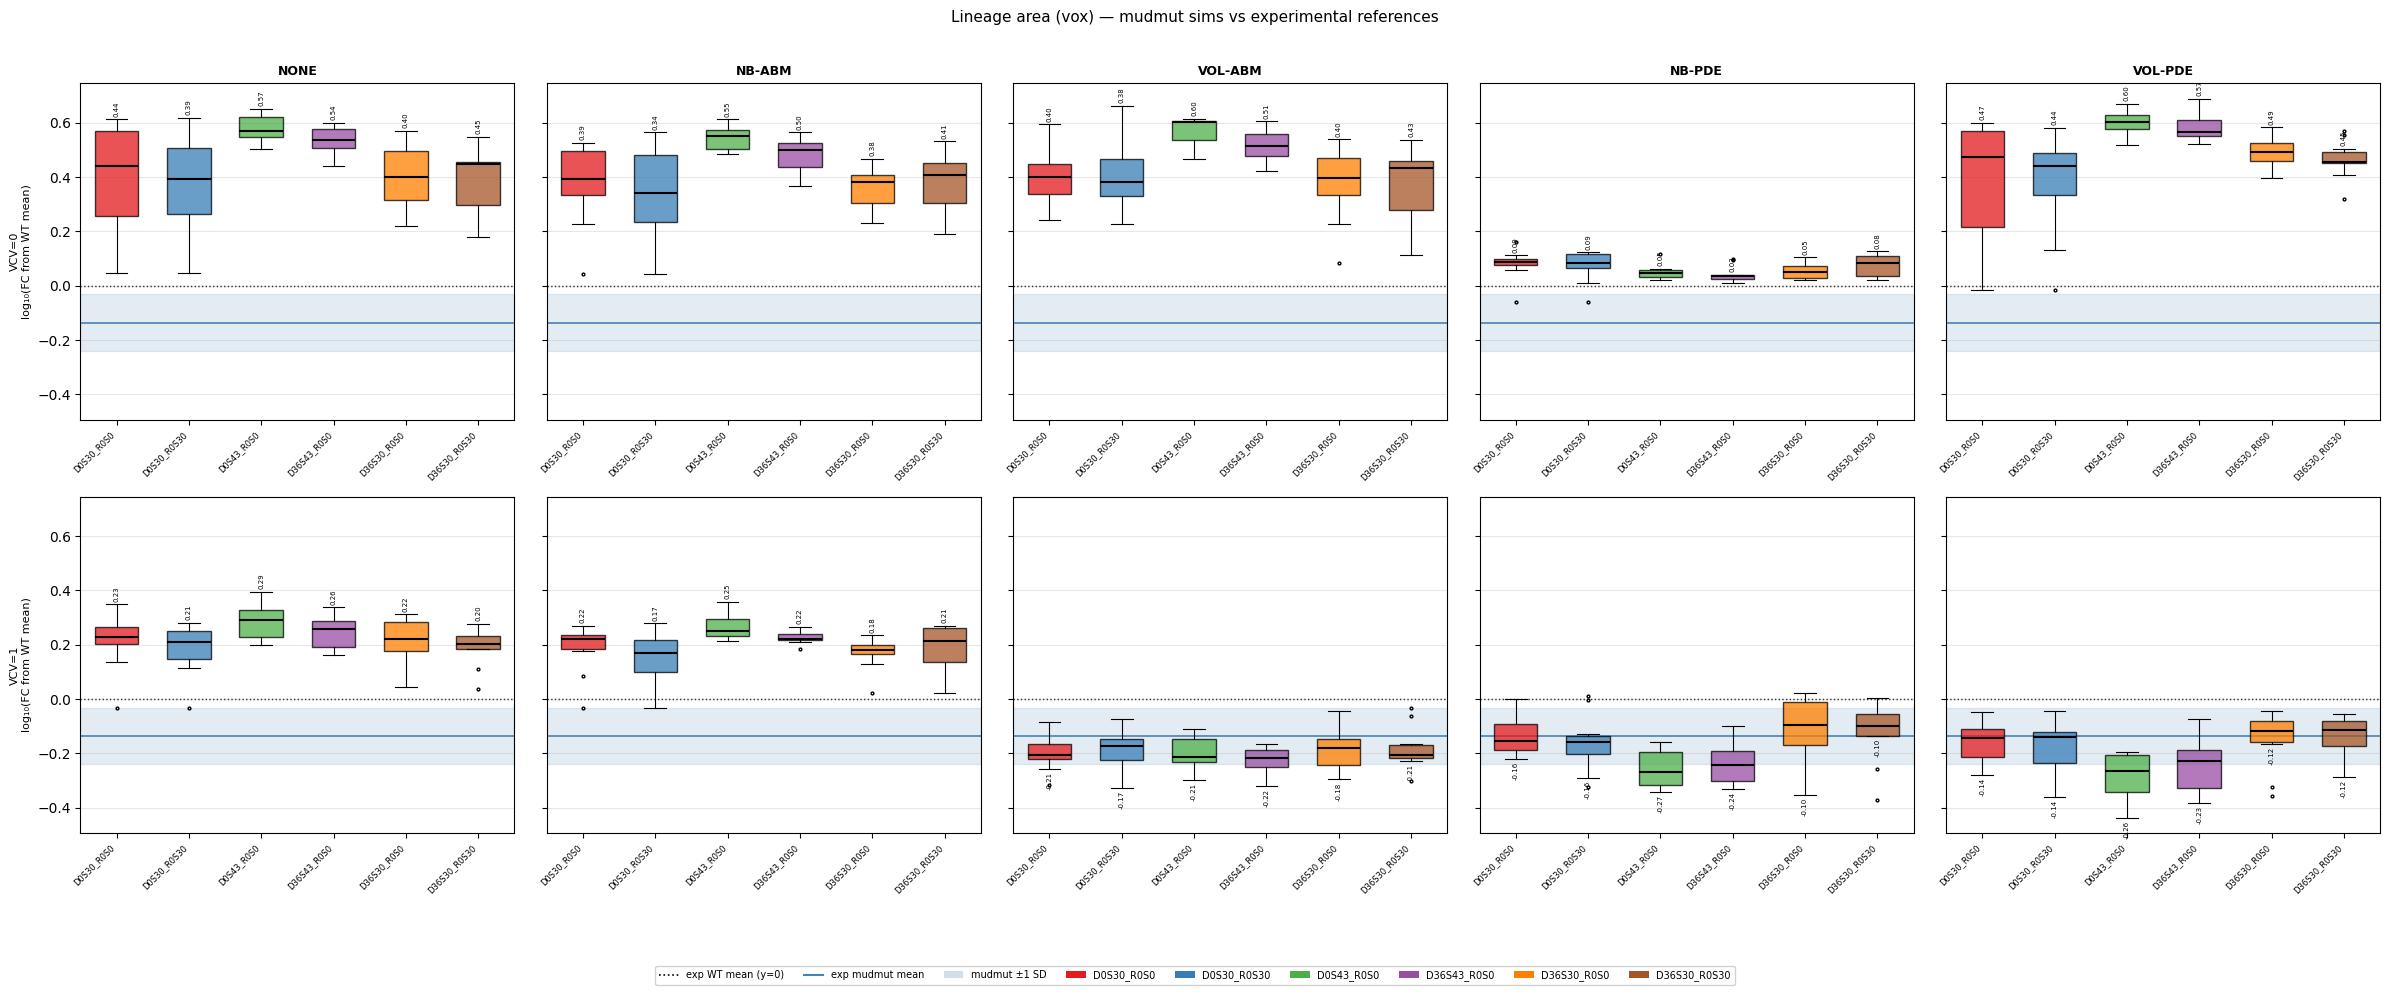

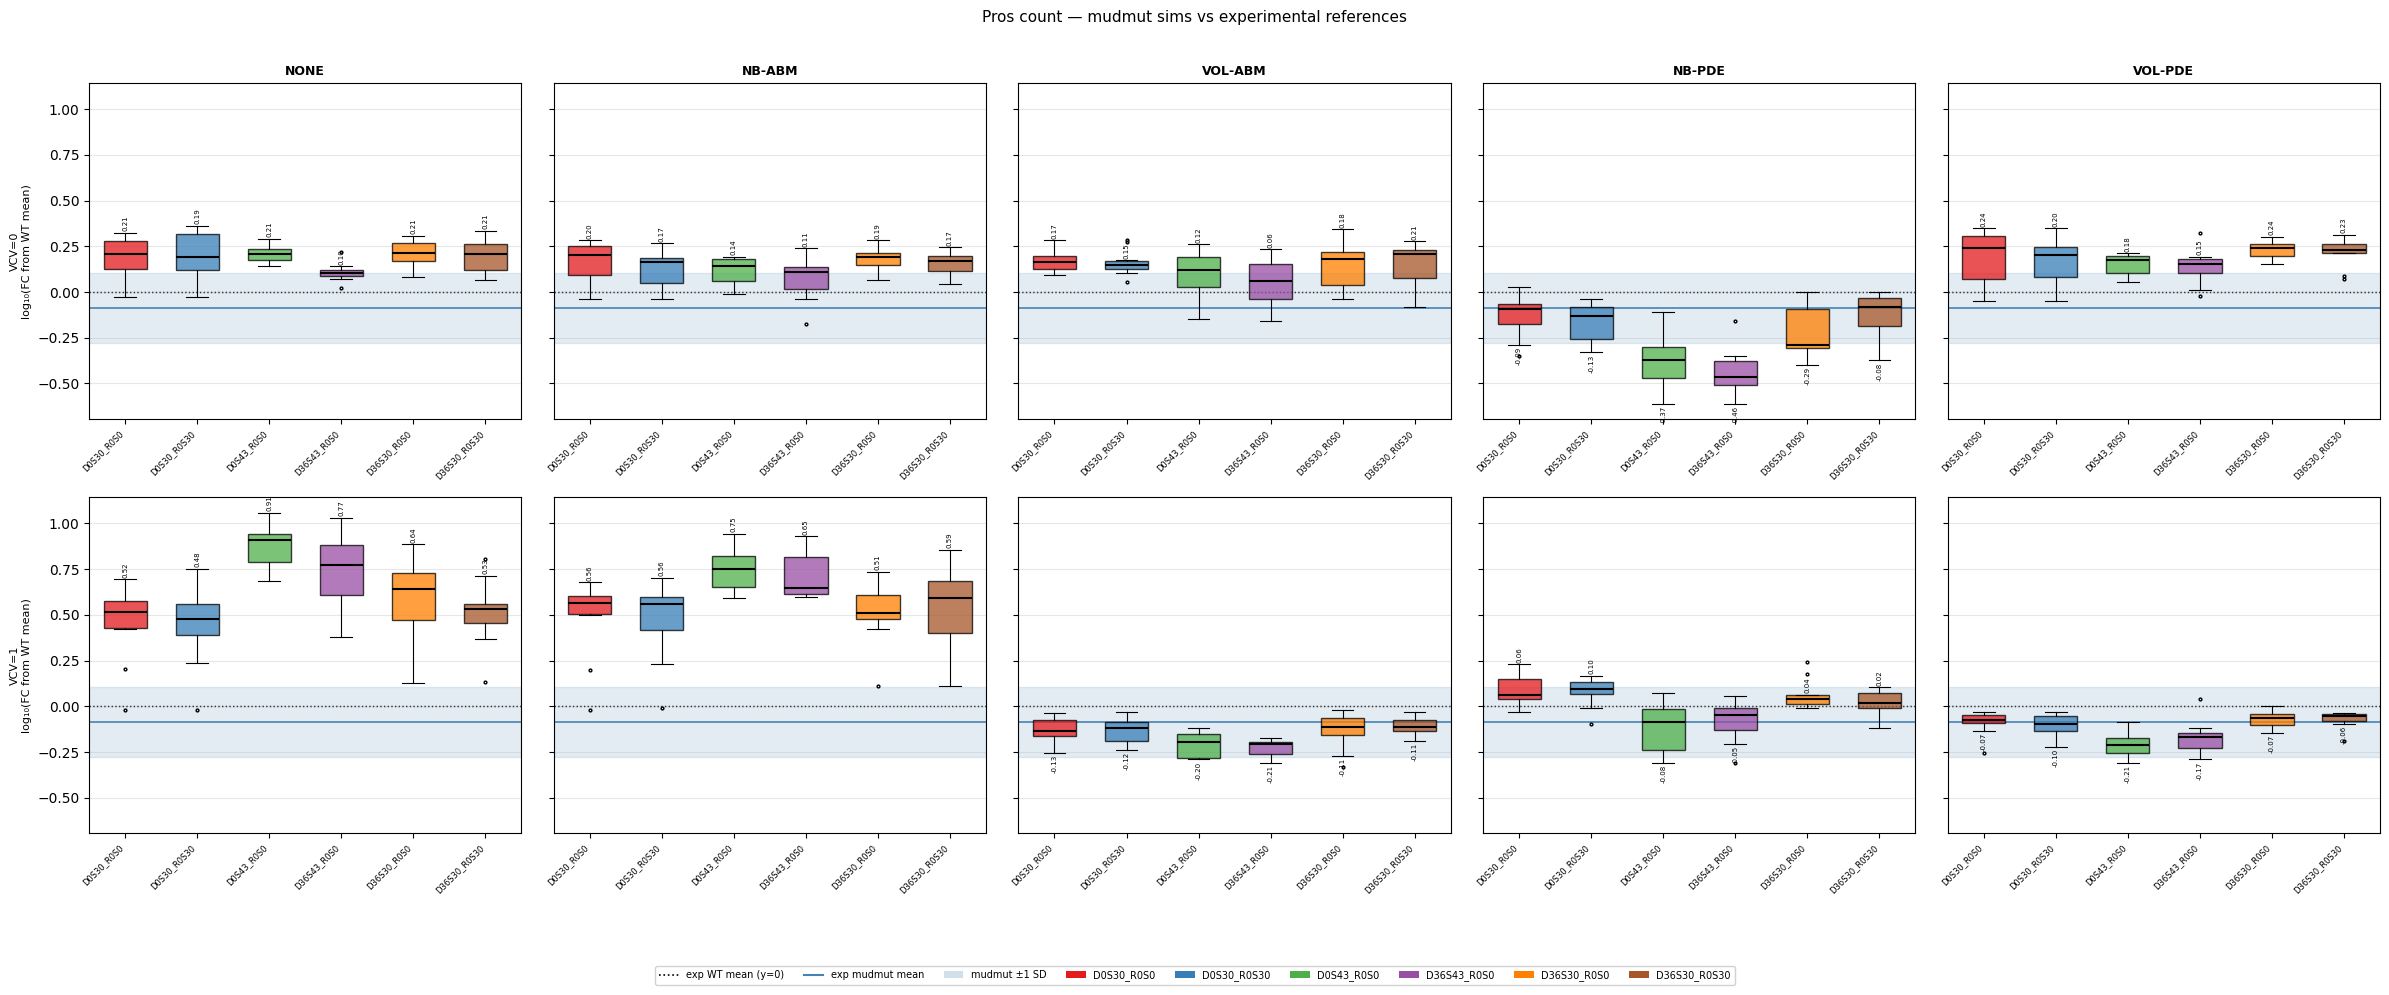

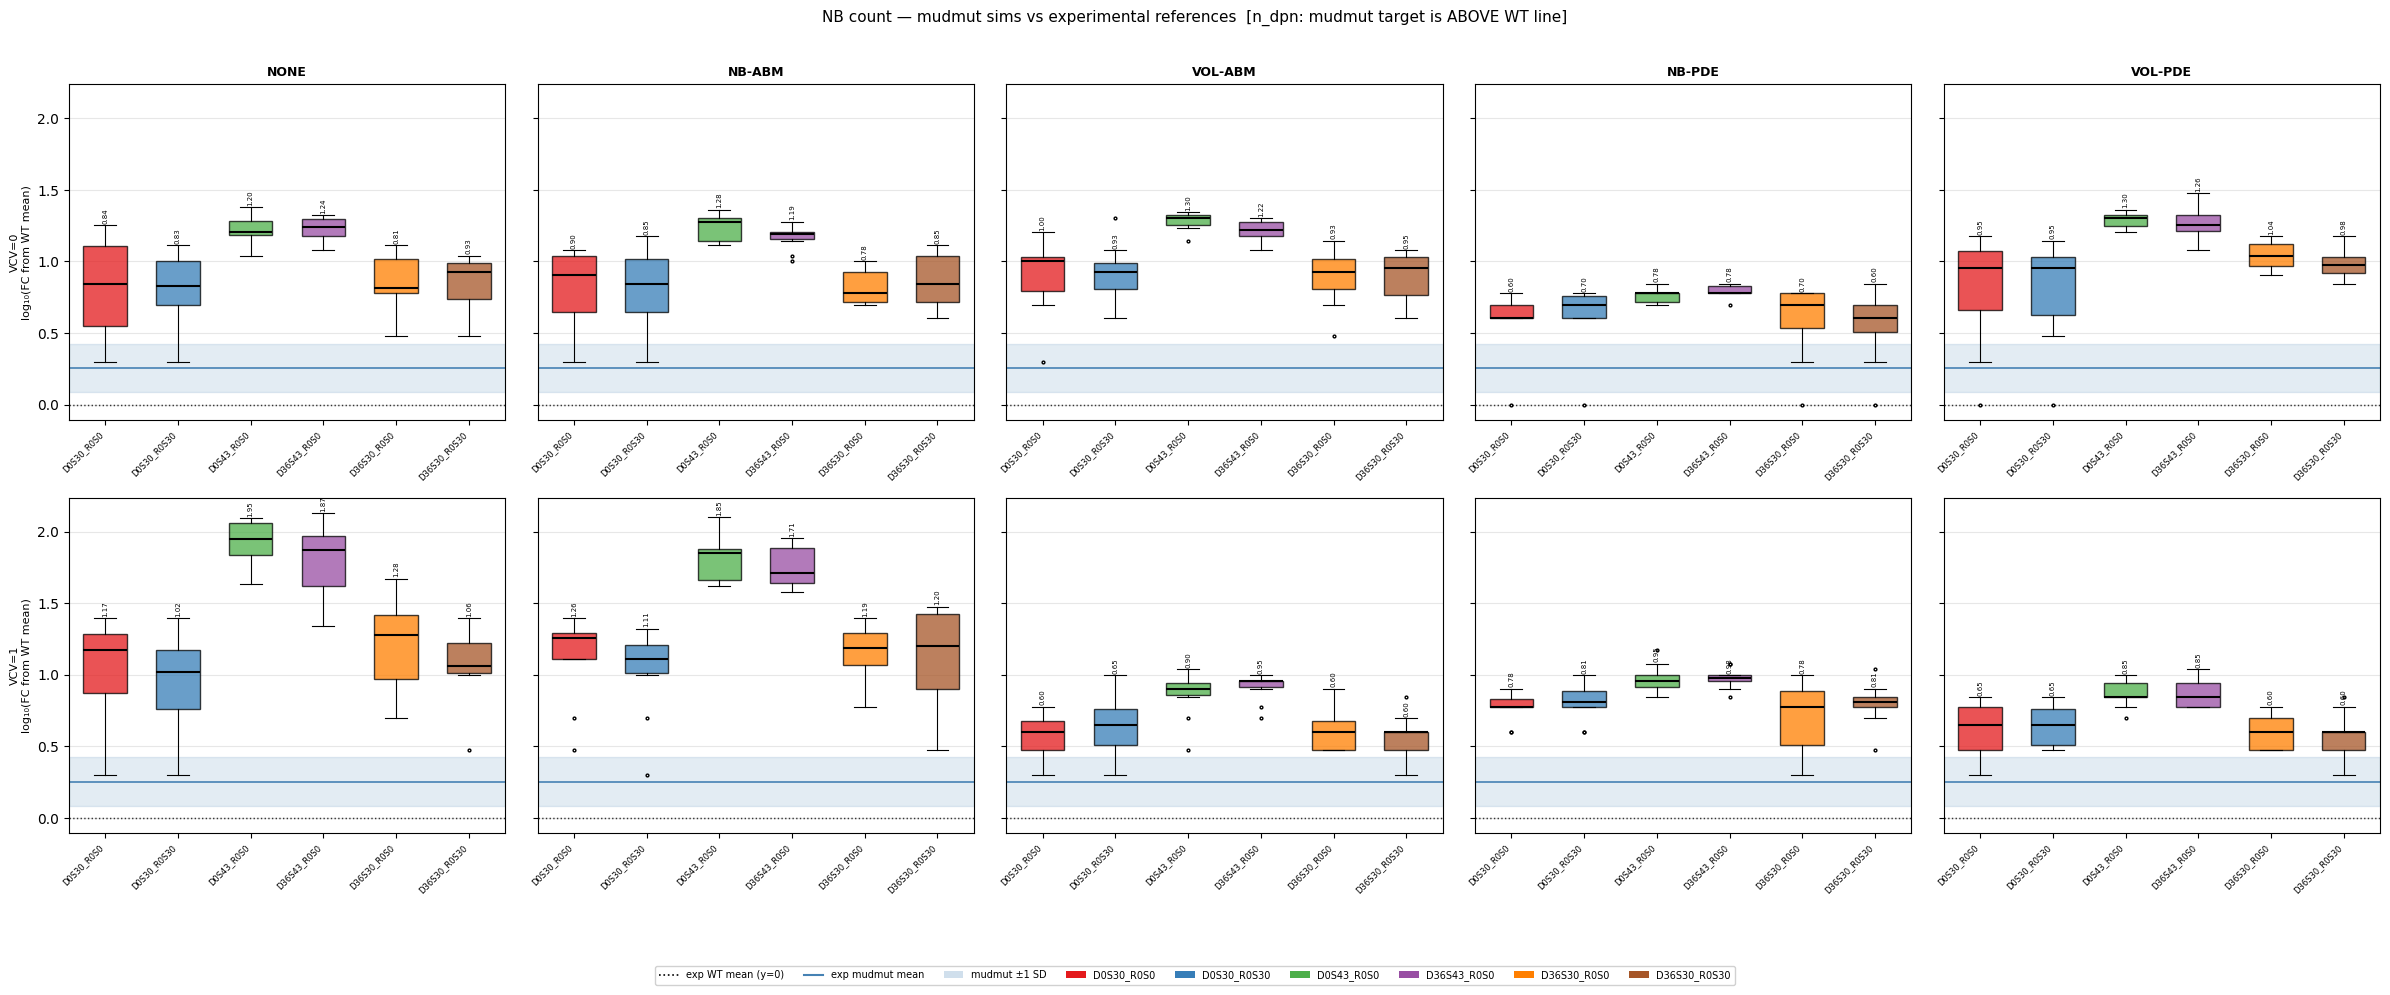

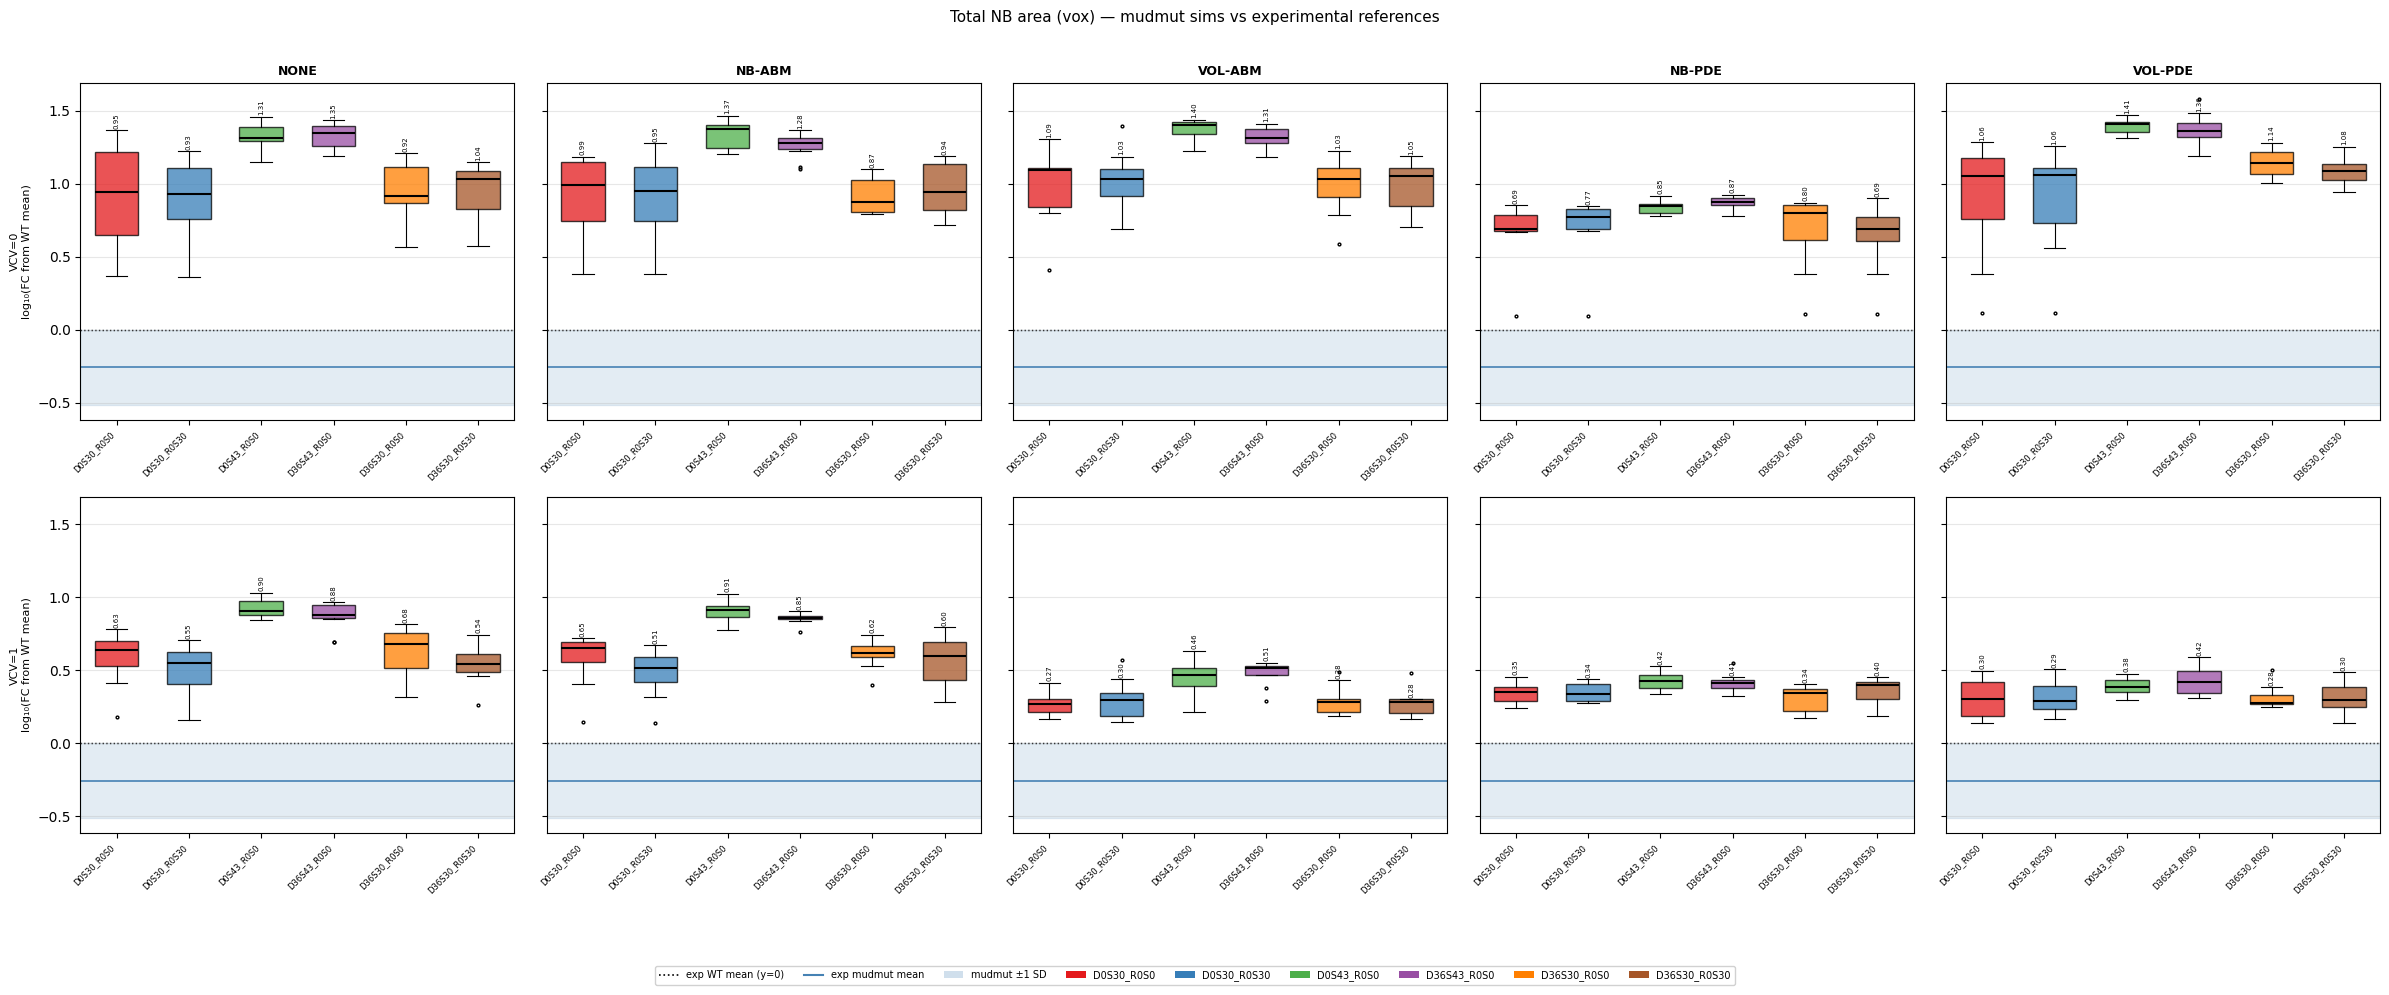

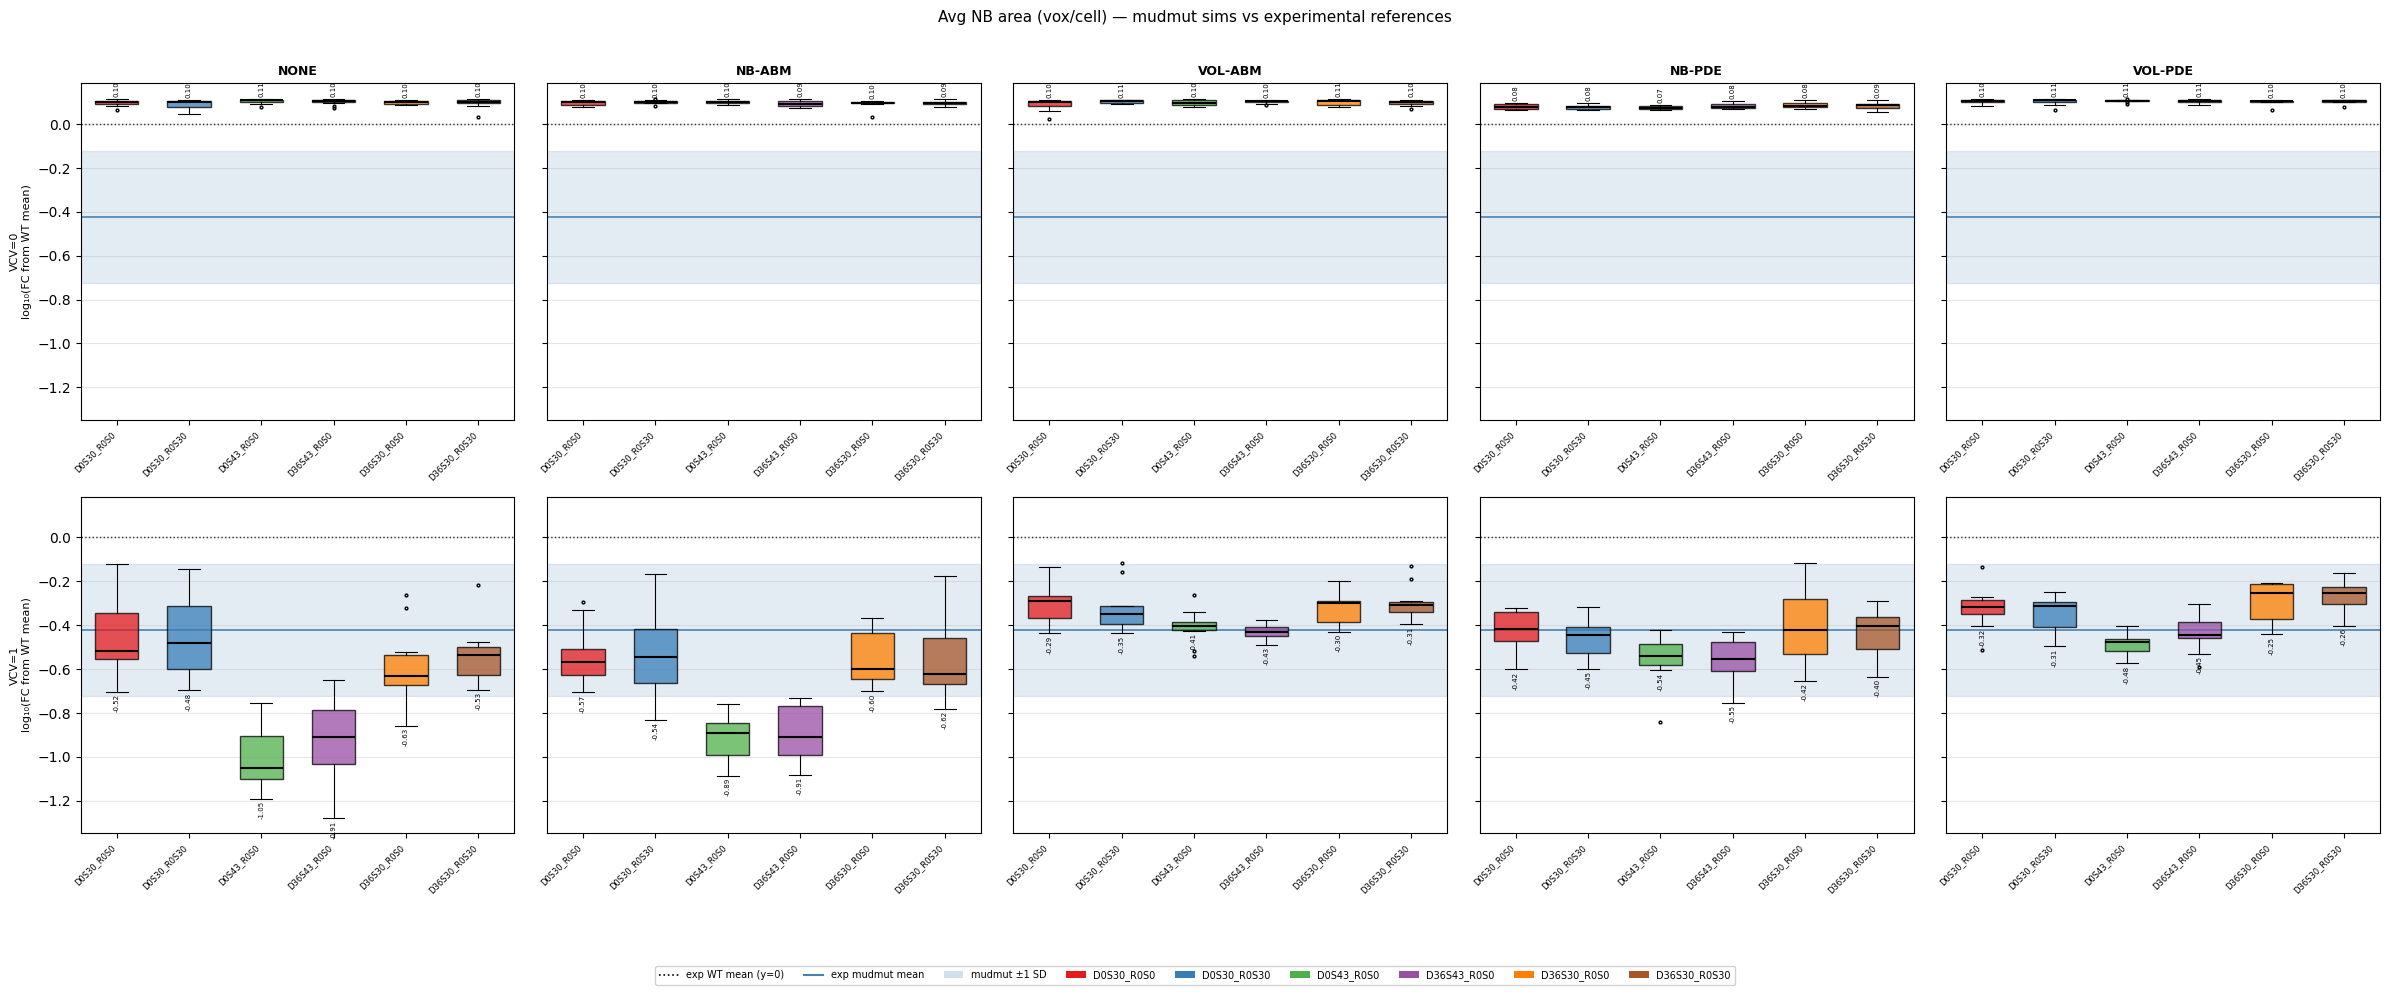

In [40]:
for metric in METRICS:
    fig = mudmut_facet_chart(metric)
    fig.savefig(FIGURES_DIR / f'sec23_{metric}.png', dpi=120, bbox_inches='tight')
    plt.show()

### Section 2+3 — Interpretation

For each metric, note:
- Which VCV=0 panels (if any) cross below the WT line / above it for n_dpn
  - Pros count for all NB-PDE regulation
  - NB count for all of them
- Which VCV=1 panels cross the WT line
  - Lineage area for VOL-ABM, NB-PDE, VOL-PDE
  - Pros count for VOL-ABM, NB-PDE for the middle two bars (D0S42_R0S0 and D36S43_R0S0), VOL-PDE
  - NB count for all
  - Average NB area for all
- Which panels enter the mudmut ±1 SD band
  - Lineage area for VOL-ABM, NB-PDE, VOL-PDE
  - Pros count for all of them (the mean for the WT is actually within this range, so even the lineages that did not get lower than WT still have means within 1 stdev of mudmut mean)
  - (None for NB count, all are actually too high)
  - (None for total NB area, all are too high)
  - Average NB area: None (no regulation) for D0S30_R0S0 and D0S30_R0S30, NB-ABM for D0S30_R0S0, D0S30_R0S30, D36S30_R0S0, D36S30_R0S30, All for VOL-ABM, NB-PDE, and VOL-PDE
- Whether any regulatory dynamic performs consistently better across angle conditions
  - NB PDE and VOL PDE

---
## Section 4 — Angle Distribution Effects

**Question:** Among accepted angle conditions, do DIV or APICAL distributions
systematically affect alignment with the experimental mudmut target?

**Y-axis:** log₁₀(value / experimental mudmut mean). The mudmut mean anchors at y=0
(solid blue line). The WT mean appears as a dotted black line above 0 (or below 0 for
n_dpn, where mudmut > WT). No shaded band is drawn since the mudmut reference is exact
at 0 in this coordinate system.

The 2-row × 5-column layout is preserved from Section 2+3 for direct comparison.

**Sub-sections:**
- **4a** — DIV_ROTATION only (APICAL = N(0,0)); isolates division-plane spread and bias
- **4b** — APICAL_ROTATION only (DIV = N(0,0)); skipped if those conditions failed roundness
- **4c** — Both parameters varying; shown alongside DIV-only counterparts to reveal interaction

In [ ]:
def mudmut_angle_chart(metric, tags_subset, figsize=(24, 10)):
    """
    2-row × 5-column facet chart with y-axis anchored at experimental mudmut mean.
    Y = log10(value / mm_mean). Mudmut mean at y=0 (solid blue); shaded band = mudmut ±1 SD
    (symmetric in log space). WT mean shown as dotted black line.
    tags_subset controls which angle conditions appear on the x-axis.
    """
    wt_mean             = wt_ref[metric][0]
    mm_mean_val, mm_std = mm_ref[metric]
    wt_lfc_from_mm      = np.log10(wt_mean / mm_mean_val)
    mm_half             = 0.05 if mm_std == 0 else np.log10(1 + mm_std / mm_mean_val)

    subset_conditions = [cond_df.loc[t, 'condition'] for t in tags_subset]

    fig, axes = plt.subplots(2, len(REG_DYN_ORDER), figsize=figsize, sharey=True)

    for ri, vcv in enumerate([0, 1]):
        for ci, reg_dyn in enumerate(REG_DYN_ORDER):
            ax = axes[ri, ci]

            ax.axhspan(-mm_half, mm_half, alpha=0.15, color='steelblue', zorder=0)
            ax.axhline(0, color='steelblue', linewidth=1.2, zorder=1)
            ax.axhline(wt_lfc_from_mm, color='black', linestyle=':', linewidth=1, zorder=1)

            panel = sim_mm[
                (sim_mm['critical_volume_mode'] == vcv) &
                (sim_mm['regulatory_dynamic']   == reg_dyn) &
                (sim_mm['condition'].isin(subset_conditions))
            ]

            data_by_tag = []
            for tag in tags_subset:
                cond = cond_df.loc[tag, 'condition']
                runs = panel[panel['condition'] == cond][metric]
                lfc  = fold_change_log(runs, mm_mean_val) if not runs.empty else np.array([np.nan])
                data_by_tag.append(lfc)

            bp = ax.boxplot(
                data_by_tag,
                positions=range(len(tags_subset)),
                widths=0.6,
                patch_artist=True,
                medianprops={'color': 'black', 'linewidth': 1.5},
                whiskerprops={'linewidth': 0.8},
                capprops={'linewidth': 0.8},
                flierprops={'marker': 'o', 'markersize': 2, 'linestyle': 'none'},
                zorder=2,
            )
            for patch, tag in zip(bp['boxes'], tags_subset):
                patch.set_facecolor(COND_COLORS[tag])
                patch.set_alpha(0.75)

            for xi, (tag, d) in enumerate(zip(tags_subset, data_by_tag)):
                if np.all(np.isnan(d)):
                    continue
                med = float(np.nanmedian(d))
                upper_cap = bp['caps'][2 * xi + 1].get_ydata()[0]
                lower_cap = bp['caps'][2 * xi].get_ydata()[0]
                if med >= 0:
                    ax.text(xi, upper_cap + 0.01, f'{med:.2f}',
                            ha='center', va='bottom', fontsize=5, rotation=90)
                else:
                    ax.text(xi, lower_cap - 0.01, f'{med:.2f}',
                            ha='center', va='top', fontsize=5, rotation=90)

            ax.set_xticks(range(len(tags_subset)))
            ax.set_xticklabels(tags_subset, rotation=45, ha='right', fontsize=6)
            ax.grid(axis='y', alpha=0.3)

            if ri == 0:
                ax.set_title(reg_dyn, fontsize=9, fontweight='bold')
            if ci == 0:
                ax.set_ylabel(f'VCV={vcv}\nlog₁₀(FC from mudmut mean)', fontsize=8)

    direction = '  [n_dpn: WT dotted line is below 0]' if metric == 'n_dpn' else ''
    fig.suptitle(
        f'{METRIC_LABELS[metric]} — angle effects  (y=0 = exp mudmut mean){direction}',
        fontsize=11,
    )

    from matplotlib.patches import Patch as _Patch
    legend_handles = [
        Line2D([0], [0], color='steelblue', linewidth=1.5, label='exp mudmut mean (y=0)'),
        _Patch(facecolor='steelblue', alpha=0.25, label='mudmut ±1 SD'),
        Line2D([0], [0], color='black', linestyle=':', linewidth=1.2, label='exp WT mean'),
    ] + [_Patch(facecolor=COND_COLORS[t], label=t) for t in tags_subset]

    fig.tight_layout(rect=[0, 0.08, 1, 0.97])
    fig.legend(handles=legend_handles, fontsize=7, loc='lower center',
               ncol=len(legend_handles), bbox_to_anchor=(0.5, 0.0), framealpha=0.9)
    return fig

### Section 4a — DIV_ROTATION alone (APICAL = N(0,0))

Restricted to conditions where APICAL is fixed at N(0,0), so only the
DIV distribution varies. X-axis ordered by increasing σ_div then μ_div.

In [ ]:
div_only_tags = sorted(
    [t for t in accepted_tags if cond_df.loc[t, 'div_only']],
    key=lambda t: (cond_df.loc[t, 'div_std'], cond_df.loc[t, 'div_mean']),
)
print(f'DIV-only accepted conditions ({len(div_only_tags)}): {div_only_tags}')

#### Section 4a-i — Varying DIV mean (std fixed)

Sort by (σ_div, μ_div): within each σ level the two μ values (0°, 36°) are adjacent,
isolating the effect of shifting the mean division angle.

In [ ]:
# Sort by (div_std, div_mean) — same-σ pairs adjacent; mean varies 0°→36° within each pair
div_mean_vary_tags = sorted(
    div_only_tags,
    key=lambda t: (cond_df.loc[t, 'div_std'], cond_df.loc[t, 'div_mean']),
)
print(f'4a-i: {div_mean_vary_tags}')
for metric in METRICS:
    fig = mudmut_angle_chart(metric, div_mean_vary_tags)
    fig.savefig(FIGURES_DIR / f'sec4a_i_{metric}.png', dpi=120, bbox_inches='tight')
    plt.show()

#### Section 4a-ii — Varying DIV std (mean fixed)

Sort by (μ_div, σ_div): within each μ level the two σ values (30°, 43°) are adjacent,
isolating the effect of broadening the division-angle spread.

In [ ]:
# Sort by (div_mean, div_std) — same-μ pairs adjacent; std varies 30°→43° within each pair
div_std_vary_tags = sorted(
    div_only_tags,
    key=lambda t: (cond_df.loc[t, 'div_mean'], cond_df.loc[t, 'div_std']),
)
print(f'4a-ii: {div_std_vary_tags}')
for metric in METRICS:
    fig = mudmut_angle_chart(metric, div_std_vary_tags)
    fig.savefig(FIGURES_DIR / f'sec4a_ii_{metric}.png', dpi=120, bbox_inches='tight')
    plt.show()

#### Section 4a-iii — Both DIV mean and std vary

Conditions are arranged so that diagonal pairs (where both μ and σ change simultaneously)
are adjacent: [lo-μ lo-σ, hi-μ hi-σ] then [lo-μ hi-σ, hi-μ lo-σ]. This lets you read
the combined effect of shifting mean while also changing spread.

In [ ]:
div_means_s = sorted(set(cond_df.loc[t, 'div_mean'] for t in div_only_tags))
div_stds_s  = sorted(set(cond_df.loc[t, 'div_std']  for t in div_only_tags))
lo_m, hi_m  = div_means_s[0], div_means_s[-1]
lo_s, hi_s  = div_stds_s[0],  div_stds_s[-1]

def _find_div_tag(dm, ds):
    return next(t for t in div_only_tags
                if cond_df.loc[t, 'div_mean'] == dm and cond_df.loc[t, 'div_std'] == ds)

# Diagonals adjacent: (lo-μ lo-σ, hi-μ hi-σ), then (lo-μ hi-σ, hi-μ lo-σ)
div_both_vary_tags = [
    _find_div_tag(lo_m, lo_s),
    _find_div_tag(hi_m, hi_s),
    _find_div_tag(lo_m, hi_s),
    _find_div_tag(hi_m, lo_s),
]
print(f'4a-iii: {div_both_vary_tags}')
for metric in METRICS:
    fig = mudmut_angle_chart(metric, div_both_vary_tags)
    fig.savefig(FIGURES_DIR / f'sec4a_iii_{metric}.png', dpi=120, bbox_inches='tight')
    plt.show()

In [ ]:
min_std_tag = min(div_only_tags, key=lambda t: (cond_df.loc[t, 'div_std'], cond_df.loc[t, 'div_mean']))
max_std_tag = max(div_only_tags, key=lambda t: (cond_df.loc[t, 'div_std'], cond_df.loc[t, 'div_mean']))

print(f'smallest σ_div: {min_std_tag}  (μ={cond_df.loc[min_std_tag,"div_mean"]}, σ={cond_df.loc[min_std_tag,"div_std"]})')
print(f'largest  σ_div: {max_std_tag}  (μ={cond_df.loc[max_std_tag,"div_mean"]}, σ={cond_df.loc[max_std_tag,"div_std"]})')

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
draw_example_lineage(
    cond_df.loc[min_std_tag, 'condition'], 'vcv1_noreg', ax=axes[0],
    title=f'mudmut VCV=1 NONE | {min_std_tag}\n(smallest σ_div = {cond_df.loc[min_std_tag,"div_std"]}°)'
)
draw_example_lineage(
    cond_df.loc[max_std_tag, 'condition'], 'vcv1_noreg', ax=axes[1],
    title=f'mudmut VCV=1 NONE | {max_std_tag}\n(largest σ_div = {cond_df.loc[max_std_tag,"div_std"]}°)'
)
plt.suptitle('Section 4a gut-check: smallest vs largest σ_div (mudmut VCV=1 NONE)', fontsize=11)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'sec4a_gutcheck.png', dpi=120, bbox_inches='tight')
plt.show()

### Section 4b — APICAL_ROTATION alone (DIV = N(0,0))

Restricted to conditions where DIV is fixed at N(0,0) (tags D0S0_R0S30, D0S0_R0S43,
D0S0_R36S43), so only the APICAL distribution varies. X-axis ordered by increasing
σ_rot then μ_rot.

If all DIV=N(0,0) conditions were excluded by the Section 1b roundness filter,
this sub-section is automatically skipped.

In [ ]:
rot_only_tags_all      = [t for t in cond_df.index if cond_df.loc[t, 'rot_only']]
rot_only_tags_accepted = [t for t in accepted_tags if cond_df.loc[t, 'rot_only']]

if not rot_only_tags_accepted:
    print(f'Section 4b SKIPPED — all APICAL-only conditions '
          f'({rot_only_tags_all}) were excluded by the roundness filter.')
else:
    rot_only_tags = sorted(
        rot_only_tags_accepted,
        key=lambda t: (cond_df.loc[t, 'rot_std'], cond_df.loc[t, 'rot_mean']),
    )
    print(f'4b conditions ({len(rot_only_tags)}): {rot_only_tags}')
    for metric in METRICS:
        fig = mudmut_angle_chart(metric, rot_only_tags)
        fig.savefig(FIGURES_DIR / f'sec4b_{metric}.png', dpi=120, bbox_inches='tight')
        plt.show()

### Section 4c — Both parameters varying

Conditions where both DIV and APICAL vary (D0S30_R0S30 and D36S30_R0S30), shown
alongside their DIV-only counterparts (D0S30_R0S0, D36S30_R0S0). This reveals
whether adding APICAL spread on top of DIV spread changes the outcome.

If neither both-varying condition survived the accepted-conditions filter, this
sub-section is automatically skipped.

In [ ]:
both_tags = [t for t in accepted_tags
             if not cond_df.loc[t, 'div_only'] and not cond_df.loc[t, 'rot_only']]

if not both_tags:
    print('Section 4c SKIPPED — no both-varying conditions remain in accepted_tags.')
else:
    div_counterparts = []
    for t in both_tags:
        dm, ds = cond_df.loc[t, 'div_mean'], cond_df.loc[t, 'div_std']
        div_counterparts.extend(
            ct for ct in accepted_tags
            if cond_df.loc[ct, 'div_only']
            and cond_df.loc[ct, 'div_mean'] == dm
            and cond_df.loc[ct, 'div_std']  == ds
        )
    sec4c_tags = sorted(
        set(div_counterparts + both_tags),
        key=lambda t: (cond_df.loc[t, 'div_std'], cond_df.loc[t, 'div_mean'],
                       cond_df.loc[t, 'rot_std']),
    )
    print(f'4c base conditions ({len(sec4c_tags)}): {sec4c_tags}')

#### Section 4c-i — Varying DIV mean (APICAL std fixed)

Sort by (σ_apical, μ_div): within each APICAL-std level (0 and 30°), the two DIV mean
values are adjacent. Isolates the effect of shifting the mean division angle while APICAL
spread is held constant.

In [ ]:
if both_tags:
    sec4c_mean_vary = sorted(
        sec4c_tags,
        key=lambda t: (cond_df.loc[t, 'rot_std'], cond_df.loc[t, 'div_mean']),
    )
    print(f'4c-i: {sec4c_mean_vary}')
    for metric in METRICS:
        fig = mudmut_angle_chart(metric, sec4c_mean_vary)
        fig.savefig(FIGURES_DIR / f'sec4c_i_{metric}.png', dpi=120, bbox_inches='tight')
        plt.show()

#### Section 4c-ii — Varying APICAL std (DIV mean fixed)

Sort by (μ_div, σ_apical): within each DIV mean level (0° and 36°), the two APICAL-std
values (0 and 30°) are adjacent. Isolates the effect of adding apical-axis rotation spread
while the division-angle mean is held constant.

In [ ]:
if both_tags:
    sec4c_std_vary = sorted(
        sec4c_tags,
        key=lambda t: (cond_df.loc[t, 'div_mean'], cond_df.loc[t, 'rot_std']),
    )
    print(f'4c-ii: {sec4c_std_vary}')
    for metric in METRICS:
        fig = mudmut_angle_chart(metric, sec4c_std_vary)
        fig.savefig(FIGURES_DIR / f'sec4c_ii_{metric}.png', dpi=120, bbox_inches='tight')
        plt.show()

#### Section 4c-iii — Both DIV mean and APICAL std vary

Diagonal pairs arranged adjacently: [lo-μ_div lo-σ_apical, hi-μ_div hi-σ_apical] then
[hi-μ_div lo-σ_apical, lo-μ_div hi-σ_apical]. Shows the combined effect when both
parameters shift simultaneously in the same or opposite directions.

In [ ]:
if both_tags:
    div_means_4c = sorted(set(cond_df.loc[t, 'div_mean'] for t in sec4c_tags))
    rot_stds_4c  = sorted(set(cond_df.loc[t, 'rot_std']  for t in sec4c_tags))
    lo_dm, hi_dm = div_means_4c[0], div_means_4c[-1]
    lo_rs, hi_rs = rot_stds_4c[0],  rot_stds_4c[-1]

    def _find_4c_tag(dm, rs):
        return next((t for t in sec4c_tags
                     if cond_df.loc[t, 'div_mean'] == dm and cond_df.loc[t, 'rot_std'] == rs), None)

    # Diagonals adjacent: (lo-μ lo-σ, hi-μ hi-σ), then (hi-μ lo-σ, lo-μ hi-σ)
    sec4c_both_vary = [t for t in [
        _find_4c_tag(lo_dm, lo_rs),
        _find_4c_tag(hi_dm, hi_rs),
        _find_4c_tag(hi_dm, lo_rs),
        _find_4c_tag(lo_dm, hi_rs),
    ] if t is not None]

    print(f'4c-iii: {sec4c_both_vary}')
    for metric in METRICS:
        fig = mudmut_angle_chart(metric, sec4c_both_vary)
        fig.savefig(FIGURES_DIR / f'sec4c_iii_{metric}.png', dpi=120, bbox_inches='tight')
        plt.show()

    # Gut-check
    example_both = both_tags[0]
    dm, ds = cond_df.loc[example_both, 'div_mean'], cond_df.loc[example_both, 'div_std']
    example_div = next(
        (t for t in accepted_tags
         if cond_df.loc[t, 'div_only']
         and cond_df.loc[t, 'div_mean'] == dm
         and cond_df.loc[t, 'div_std']  == ds),
        None,
    )
    fig2, axes2 = plt.subplots(1, 2, figsize=(11, 5))
    draw_example_lineage(
        cond_df.loc[example_both, 'condition'], 'sim41', ax=axes2[0],
        title=f'mudmut VCV=1 NONE | {example_both}\n(both DIV+APICAL varying)'
    )
    if example_div:
        draw_example_lineage(
            cond_df.loc[example_div, 'condition'], 'sim41', ax=axes2[1],
            title=f'mudmut VCV=1 NONE | {example_div}\n(DIV-only counterpart)'
        )
    plt.suptitle('Section 4c gut-check: both-varying vs DIV-only counterpart', fontsize=11)
    plt.tight_layout()
    fig2.savefig(FIGURES_DIR / 'sec4c_gutcheck.png', dpi=120, bbox_inches='tight')
    plt.show()

### Section 4 — Interpretation

*Record observations here after running the cells above.*

Key questions to address:
- Does increasing DIV spread (larger σ_div) consistently move simulations toward or away from the mudmut target?
- Does a biased mean (μ_div = 36°) improve or worsen alignment relative to zero mean?
- For conditions in 4c, does adding APICAL spread change the outcome relative to DIV alone?
- Are angle-condition effects consistent across regulatory dynamics, or do they interact?

---
## Section 5 — Synthesis

**Goal:** identify the best-performing (VCV, regulatory dynamic, angle condition) combinations
across the top 3 metrics.

**Method:** for each metric, rank all combinations by the fraction of simulated runs falling
within the experimental mudmut ±1 SD band (same band used in Sections 2+3). A combined rank
(sum of per-metric ranks across the 3 top metrics) identifies the overall best performers.

In [ ]:
records = []
for metric in TOP3:
    wt_mean             = wt_ref[metric][0]
    mm_mean_val, mm_std = mm_ref[metric]
    mm_lfc              = np.log10(mm_mean_val / wt_mean)
    mm_half             = 0.05 if mm_std == 0 else np.log10(1 + mm_std / mm_mean_val)
    mm_lo, mm_hi        = mm_lfc - mm_half, mm_lfc + mm_half

    for vcv in [0, 1]:
        for reg_dyn in REG_DYN_ORDER:
            for tag in accepted_tags:
                cond = cond_df.loc[tag, 'condition']
                runs = sim_mm[
                    (sim_mm['critical_volume_mode'] == vcv) &
                    (sim_mm['regulatory_dynamic']   == reg_dyn) &
                    (sim_mm['condition']            == cond)
                ][metric]
                if runs.empty:
                    continue
                lfc = fold_change_log(runs, wt_mean)
                frac_within = float(np.mean((lfc >= mm_lo) & (lfc <= mm_hi)))
                records.append({
                    'metric':              metric,
                    'vcv':                 vcv,
                    'regulatory_dynamic':  reg_dyn,
                    'condition':           tag,
                    'frac_within_mm_band': round(frac_within, 3),
                    'mean_log_fc_from_mm': round(float(np.mean(lfc)) - mm_lfc, 3),
                })

proximity_df = pd.DataFrame(records)
proximity_df['rank'] = proximity_df.groupby('metric')['frac_within_mm_band'].rank(
    ascending=False, method='min'
).astype(int)

print('=== Per-metric top 10 ===')
for metric in TOP3:
    print(f'\n── {METRIC_LABELS[metric]} ──')
    top10 = (
        proximity_df[proximity_df['metric'] == metric]
        .sort_values(['frac_within_mm_band', 'mean_log_fc_from_mm'],
                     ascending=[False, True])
        .head(10)
        [['rank', 'vcv', 'regulatory_dynamic', 'condition',
          'frac_within_mm_band', 'mean_log_fc_from_mm']]
    )
    print(top10.to_string(index=False))

# Combined rank: sum of per-metric ranks (lower = better)
combo_rank = (
    proximity_df.groupby(['vcv', 'regulatory_dynamic', 'condition'])['rank']
    .sum()
    .reset_index()
    .rename(columns={'rank': 'combined_rank'})
    .sort_values('combined_rank')
    .reset_index(drop=True)
)
combo_rank.index += 1
combo_rank.index.name = 'overall_rank'

print('\n=== Combined rank (sum of per-metric ranks across top-3 metrics) ===')
print(combo_rank.head(20).to_string())

### Section 5 — Interpretation

*Record conclusions here after reviewing the synthesis tables above.*

Key questions to address:
- Which regulatory mechanisms show the most promise across all three primary metrics?
- Is VCV=1 necessary to approach the mudmut target, or do VCV=0 conditions sometimes rank well?
- Does any angle condition consistently improve or worsen alignment across regulatory dynamics?
- Which single (VCV, regulatory dynamic, angle condition) combination best reproduces the experimental mudmut phenotype overall?